## Run 'pl' script

In [3]:
prego::compute_pwm

function (sequences, pssm, spat = NULL, spat_min = 1, spat_max = NULL, 
    bidirect = TRUE, prior = 0.01, func = "logSumExp") 
{
    if (is.null(spat)) {
        spat <- data.frame(bin = 0, spat_factor = 1)
        binsize <- nchar(sequences[[1]])
    }
    else {
        validate_spat(spat)
        binsize <- unique(diff(spat$bin))
    }
    if (is.null(spat_max)) {
        spat_max <- nchar(sequences[[1]])
    }
    if (is.null(spat_min)) {
        spat_min <- 1
    }
    if (!(spat_min == 1 && spat_max == nchar(sequences[[1]]))) {
        sequences <- stringr::str_sub(sequences, start = spat_min, 
            end = spat_max)
    }
    if (!all(c("A", "C", "G", "T") %in% colnames(pssm))) {
        cli_abort("The {.field pssm} matrix should have columns {.val A}, {.val C}, {.val G}, {.val T}")
    }
    pssm_mat <- as.matrix(pssm[, c("A", "C", "G", "T")])
    if (prior < 0 || prior > 1) {
        cli_abort("The {.field prior} should be between 0 and 1")
    }
    if (prior > 0) {
        pssm_mat <- pssm_mat + prior
    }
    if (func == "max") {
        use_max <- TRUE
    }
    else if (func == "logSumExp") {
        use_max <- FALSE
    }
    else {
        cli_abort("The {.field func} argument should be either {.val max} or {.val logSumExp}")
    }
    pwm <- compute_pwm_cpp(sequences = toupper(sequences), pssm_mat = pssm_mat, 
        is_bidirect = bidirect, spat_min = 0, spat_max = nchar(sequences[1]), 
        spat_factor = spat$spat_factor, bin_size = binsize, use_max = use_max)
    return(pwm)
}
<bytecode: 0x55f80b120a28>
<environment: namespace:prego>

In [4]:
prego::compute_pwm_cpp

ERROR: Error: 'compute_pwm_cpp' is not an exported object from 'namespace:prego'


In [39]:
library(metacell)

wd = '/net/mraid14/export/tgdata/users/yonshap/proj/mmcortex'
set.seed(1337)

db_path = file.path(wd, 'scdb')
if (!dir.exists(db_path)) {dir.create(db_path)}
scdb_init(db_path, force_reinit = T)
scfigs_init(file.path(wd, "figs"))

nm = 'pl'

mat = scdb_mat(nm)

mc = scdb_mc(nm)

mg_bon = read.delim('./BonevCollab//marker_genes.tsv', sep='\t') %>% 
            apply(1, function(x) stringr::str_split(x, pattern = ' ')) %>%
            purrr::map(1) %>% purrr::map(function(x) c(x[[1]], stringr::str_split(x[[length(x)]], ',')))

mg_bon = unique(data.frame(cbind(purrr::map(mg_bon, 1), purrr::map(mg_bon, 2))))
colnames(mg_bon) = c('st', 'marks')
# mg_bon


feats = scdb_gset(paste0(nm, '_f'))
feats = names(feats@gene_set)

legc <- log2(1e-5 + mc@e_gc)

dim(legc)

non_cort_genes = c('Reln', 'Lhx5','Gad2', 'Sst' , 'Lhx6', 'Nrxn3','Gsx2','Dlx2','Aif1', 'C1qb', 'Hexb', 'Igfbp7')
non_cort_mcs = sort(unique(unlist(sapply(non_cort_genes, function(g) which(mc@mc_fp[g,] >= 1.5)))))
non_cort_mcs
non_cort_cells = names(mc@mc)[mc@mc %in% non_cort_mcs]

cells_ignore_new = union(non_cort_cells, mat@ignore_cells)

ca <- as.data.frame(as.numeric(1:ncol(legc) %in% non_cort_mcs))
colnames(ca) <- 'is_non_cort'
rownames(ca) <- 1:nrow(ca)
ac <- list(is_non_cort = setNames(c('black', 'red'), c(0,1)))

options(repr.plot.width = 10)
options(repr.plot.height = 6)

p_filt_non_cort_rna <- pheatmap::pheatmap(legc[c('Fabp7',unique(unlist(mg_bon$marks))),], annotation_col = ca, annotation_colors = ac, clustering_method = 'ward.D2', fontsize = 14,
                   show_colnames = F, treeheight_col = 0, treeheight_row = 0, col = colorRampPalette(c('white', 'orange', 'red', 'purple', 'black'))(100))

mcATAC::save_pheatmap(p_filt_non_cort_rna, './output/metacell_model/figs/filt_non_cort_rna_metacells_phm.png', h = 1200, w = 2000)

In [2]:
dim(mc@e_gc)

[1] 18715   521

In [ ]:
nm_new = paste0(nm, '_cort')

mcell_mat_ignore_cells(new_mat_id = nm_new, mat_id = nm, ig_cells = cells_ignore_new, reverse = F)

In [1]:
library(metacell)


wd = '/net/mraid14/export/tgdata/users/yonshap/proj/mmcortex'

set.seed(1337)


db_path = file.path(wd, 'scdb')
if (!dir.exists(db_path)) {dir.create(db_path)}
scdb_init(db_path, force_reinit = T)
scfigs_init(file.path(wd, "figs"))

initializing scdb to /net/mraid14/export/tgdata/users/yonshap/proj/mmcortex/scdb



In [2]:
mat = scdb_mat('pl')

In [3]:
mc = scdb_mc('pl')

In [4]:
mcell_gset_from_mc_markers(gset_id = 'pl_marks', mc_id = 'pl', blacklist_gset_id = 'pl_lateral')

In [4]:
marks = scdb_gset('pl_marks')

In [17]:
lat = scdb_gset('pl_lateral')

In [5]:
mg_bon = read.delim('./BonevCollab//marker_genes.tsv', sep='\t') %>% 
            apply(1, function(x) stringr::str_split(x, pattern = ' ')) %>%
            purrr::map(1) %>% purrr::map(function(x) c(x[[1]], stringr::str_split(x[[length(x)]], ',')))

mg_bon = unique(data.frame(cbind(purrr::map(mg_bon, 1), purrr::map(mg_bon, 2))))
colnames(mg_bon) = c('st', 'marks')
mg_bon

,st,marks
,<list>,<list>
1,NSC,"Pax6, Sox2, Vim , Hes1, Id4 , Gas1"
2,IPC,"Neurog2, Eomes , Btg2 , Gadd45g"
3,CthPN,"Sox5 , Tle4 , Bcl11b"
4,SCPN,"Fezf2 , Ldb2 , Bcl11b"
5,Stellate_L4,"Rorb , Satb2, Cux1 , Lpl"
6,CPN_L2-3,"Cux1 , Cux2 , Satb2 , Pou3f2"
7,CPN_L5_6,"Satb2, Ldb2"
8,CR,"Reln, Lhx5"
9,IN_MGE,"Gad2, Sst , Lhx6"


In [32]:
# mg_bon_marks = sort(unique(unlist(mg_bon$marks)))
# t(mc@mc_fp[mg_bon_marks,])

In [33]:
# sapply(sort(unique(unlist(mg_bon$marks))), function(g) mcell_mc2d_plot_gene('pl', g))

### Cluster mgraph

In [13]:
library(igraph)

mg = scdb_mgraph('pl')

mg = mg@mgraph

eg = igraph::graph_from_edgelist(el = as.matrix(mg[,c('mc1', 'mc2')]), directed = F)

eg_louv = cluster_louvain(graph = eg, weights = mg$dist)

eg_louv

groups(eg_louv)

ind_louv = unlist(lapply(seq_along(groups(eg_louv)), function(x,n,i) {setNames(x[[i]], rep(n[[i]], length(x[[i]])))},x = groups(eg_louv), n=names(groups(eg_louv))))

In [22]:
manual_color_key = setNames(sample(grep('white|grey|gray', colors(), inv=T, v=T), length(groups(eg_louv))), 1:length(groups(eg_louv)))

manual_color_key

1                2                3                4 
         "azure"        "purple3"         "green3"          "beige" 
               5                6                7                8 
 "darkgoldenrod"     "lightcyan2"    "aquamarine2"     "royalblue3" 
               9               10               11               12 
"lavenderblush2" "darkgoldenrod4"        "orange3"  "mediumpurple1" 
              13               14               15               16 
     "orangered"     "slateblue3"   "lemonchiffon"          "gold3" 
              17               18               19               20 
        "khaki3"        "maroon3"           "tan3"       "moccasin"

In [23]:
manual_colors = unlist(sapply(seq_along(unique(names(ind_louv))), function(ind, clr, i) {
    ind_f = as.numeric(names(ind_louv)) == i;
    setNames(rep(clr[[i]], length(which(ind_f))), ind_louv[ind_f])
                 }, ind=ind_louv, clr=manual_color_key))

In [14]:
fp_cl = t(tgs_matrix_tapply(mc@mc_fp, as.numeric(names(ind_louv)), mean))

In [35]:
legcz_marks = mc@mc_fp[sort(unique(unlist(mg_bon$marks))),]


In [117]:
non_cort_genes = c('Reln', 'Lhx5','Gad2', 'Sst' , 'Lhx6', 'Nrxn3','Gsx2','Dlx2','Aif1', 'C1qb', 'Hexb', 'Igfbp7')

In [122]:
peri_genes = c('Vtn', 'Rgs5', 'Igfbp7', 'Cspg4', 'Pdgfrb', 'Lgals1', 'Car2', 'Lum', 'Col3a1')

In [123]:
sapply(peri_genes, function(g) which(mc@mc_fp[g,] >= 1.5))

$Vtn
439 
439 

$Rgs5
439 443 
439 443 

$Igfbp7
439 440 
439 440 

$Cspg4
  5 439 
  5 439 

$Pdgfrb
  7 439 
  7 439 

$Lgals1
 10  23  27  62 438 439 
 10  23  27  62 438 439 

$Car2
407 408 410 411 412 413 414 419 439 440 
407 408 410 411 412 413 414 419 439 440 

$Lum
named integer(0)

$Col3a1
439 
439

In [116]:
head(sort(mc@mc_fp[,23], decreasing = T), 10)

Hmgb2 Hist1h2ap       Dbi     Fabp7     Top2a      Hes5     Cenpf  Hist1h1b 
21.388633 21.007419 13.663769 13.431445 13.416838 12.465330 10.324424 10.295021 
      Vim     Ube2c 
 9.419763  8.924786

In [118]:
sapply(non_cort_genes, function(g) which(mc@mc_fp[g,] >= 1.5))

$Reln
416 417 418 422 423 424 434 442 443 457 
416 417 418 422 423 424 434 442 443 457 

$Lhx5
442 443 
442 443 

$Gad2
  2   3 406 407 408 409 410 411 412 413 414 415 416 417 418 419 420 421 422 423 
  2   3 406 407 408 409 410 411 412 413 414 415 416 417 418 419 420 421 422 423 
424 425 426 427 428 429 430 431 432 433 434 435 436 
424 425 426 427 428 429 430 431 432 433 434 435 436 

$Sst
406 409 414 415 416 417 418 421 422 423 424 425 
406 409 414 415 416 417 418 421 422 423 424 425 

$Lhx6
406 407 408 409 410 411 412 413 414 415 416 417 418 419 420 421 422 423 424 425 
406 407 408 409 410 411 412 413 414 415 416 417 418 419 420 421 422 423 424 425 

$Nrxn3
  2   3 406 407 408 409 410 411 412 413 414 415 416 417 418 419 420 421 422 423 
  2   3 406 407 408 409 410 411 412 413 414 415 416 417 418 419 420 421 422 423 
424 425 426 427 428 429 430 431 432 433 434 435 436 447 457 458 
424 425 426 427 428 429 430 431 432 433 434 435 436 447 457 458 

$Gsx2
2 
2 

$Dlx2
  2   3 406 407 408 409 410 411 412 413 414 415 416 417 418 419 420 421 422 423 
  2   3 406 407 408 409 410 411 412 413 414 415 416 417 418 419 420 421 422 423 
424 425 426 427 428 429 430 431 432 434 435 436 
424 425 426 427 428 429 430 431 432 434 435 436 

$Aif1
437 438 441 
437 438 441 

$C1qb
437 438 441 
437 438 441 

$Hexb
437 438 441 
437 438 441 

$Igfbp7
439 440 
439 440

In [113]:
apply(mc@mc_fp[non_cort_genes, !(1:ncol(mc@mc_fp) %in% non_cort_mcs)], 1, max)

Reln     Lhx5     Gad2      Sst     Lhx6    Nrxn3     Gsx2     Dlx2 
1.409803 1.031109 1.197943 1.131569 1.111501 1.339152 1.370412 1.362192 
    Aif1     C1qb     Hexb 
1.050193 1.056958 1.279949

In [119]:
non_cort_mcs = sort(unique(unlist(sapply(non_cort_genes, function(g) which(mc@mc_fp[g,] >= 1.5)))))
                                         non_cort_mcs

[1]   2   3 406 407 408 409 410 411 412 413 414 415 416 417 418 419 420 421 422
[20] 423 424 425 426 427 428 429 430 431 432 433 434 435 436 437 438 439 440 441
[39] 442 443 447 457 458

In [120]:
length(mc@mc)

[1] 45401

In [121]:
length(mc@mc[!(mc@mc %in% non_cort_mcs)])

[1] 41487

In [110]:
mcell_mc2d_plot('pl', colors = ifelse(1:length(unique(mc@mc)) %in% non_cort_mcs, 'red', 'black'), fn_suf = '_test_non_cort_mcs')

png 
  2

In [108]:
sort(table(unlist(sapply(non_cort_genes, function(g) which(mc@mc_fp[g,] >= 1.5)))), decreasing = T)


416 417 418 422 423 424 406 409 414 415 421 425   2 407 408 410 411 412 413 419 
  6   6   6   6   6   6   5   5   5   5   5   5   4   4   4   4   4   4   4   4 
420 434   3 426 427 428 429 430 431 432 435 436 437 438 441 433 442 443 457 447 
  4   4   3   3   3   3   3   3   3   3   3   3   3   3   3   2   2   2   2   1 
458 
  1 

In [100]:
head(sort(mc@mc_fp[,2], decreasing = T), 10)

Ccnd2     Hmgn2      Dlx1     Hmgb2       Arx       Sp9      Dlx2   Dlx6os1 
16.556959  6.281425  5.640471  5.158458  5.026873  4.841837  4.820111  4.745070 
    Cdca7       Dbi 
 4.249317  4.063881

In [101]:
head(sort(mc@mc_fp[,3], decreasing = T), 10)

Hmgb2     Ube2c     Ccnd2     Top2a     Cenpf      Cks2     Birc5     Cenpa 
20.983717 13.245447  9.840604  9.713920  9.390404  7.630344  7.468809  7.230264 
Hist1h2ap     Mki67 
 6.318195  5.901701

In [95]:
head(sort(mc@mc_fp[,447], decreasing = T), 10)

Mef2c   Tubb2a    Stmn2     Mapt    Gap43     Rac3     Syt4    Stmn4 
7.708325 5.365028 5.329812 5.038729 3.785036 3.140999 2.930586 2.894432 
  Hbb-bs      Ina 
2.886903 2.756791

In [98]:
head(sort(mc@mc_fp[,262], decreasing = T), 10)

Pcp4   Zbtb20     Rnd2    Unc5d     Nrn1   Sema3c  Neurod1      Ezr 
5.232478 4.401271 3.751934 3.408098 3.401568 3.269425 3.124730 3.067752 
   Sstr2    Plcb1 
2.955609 2.899175

In [89]:
head(sort(mc@mc_fp[,442], decreasing = T), 10)

Reln     Nhlh2      Nnat     Nr2f2      Meg3       Ina  Cacna2d2     Calb2 
14.592571  7.673429  6.118772  5.518305  5.138422  4.831132  4.736730  4.085482 
    Gap43   Gadd45g 
 4.010367  3.919119

In [90]:
head(sort(mc@mc_fp[,443], decreasing = T), 10)

Gap43     Pcp4     Reln    Calb2    Stmn2   Tubb2a     Ndnf     Ly6h 
8.568847 7.886384 6.579309 5.509043 4.856520 4.476383 4.302576 3.851994 
   Nhlh2   Pcsk1n 
3.834155 3.293114

In [86]:
head(sort(mc@mc_fp[,437], decreasing = T), 10)

Apoe     C1qb     C1qc     C1qa     Ctsd     Hexb   Tyrobp   Cx3cr1 
55.33067 32.15364 26.96485 23.77799 23.67467 21.82282 21.28562 17.16463 
  Fcer1g     Lgmn 
15.03247 14.98403

In [86]:
head(sort(mc@mc_fp[,437], decreasing = T), 10)

Apoe     C1qb     C1qc     C1qa     Ctsd     Hexb   Tyrobp   Cx3cr1 
55.33067 32.15364 26.96485 23.77799 23.67467 21.82282 21.28562 17.16463 
  Fcer1g     Lgmn 
15.03247 14.98403

In [87]:
head(sort(mc@mc_fp[,438], decreasing = T), 10)

Apoe    Tyrobp      C1qb      C1qa      Aif1    Fcer1g      C1qc    Arpc1b 
21.749495 17.630813 17.109827 11.827824 11.296305 11.177143 10.659999 10.040646 
     Ctsd     Rgs10 
 9.436031  8.959419

In [88]:
head(sort(mc@mc_fp[,441], decreasing = T), 10)

Apoe      C1qb      C1qa    Tyrobp      C1qc    Fcer1g      Hexb      Cst3 
33.465664 24.183740 17.116192 16.935312 16.725036 14.858714 13.663997 10.206778 
     Ctsd    Crybb1 
10.194556  9.377529

In [82]:
head(sort(mc@mc_fp[,439], decreasing = T), 10)

Rgs5       Vtn     Cald1    Col4a1    Igfbp7     Gng11  Ndufa4l2    Atp1a2 
30.937436 14.167076 12.527748 12.225907 11.766617 11.118798 10.823817  8.401996 
    Sparc  Serpinh1 
 7.813582  7.708748

In [83]:
head(sort(mc@mc_fp[,440], decreasing = T), 10)

Cldn5     Sparc    Igfbp7     Ramp2    Col4a1     Gng11     Itm2a    Slc2a1 
18.892333 12.640462 11.549167  7.628656  6.965092  6.457846  6.221178  5.986082 
    Egfl7    Col4a2 
 5.710619  5.580046

In [85]:
head(sort(mc@mc_fp[,5], decreasing = T), 10)

Fabp7     Olig1    Pdgfra    Ptprz1     Cspg5     Olig2     Ncald        Qk 
20.901198 15.995204  8.846131  7.624470  7.127228  6.123742  5.932990  5.440295 
 Serpine2     Ednrb 
 5.232311  4.926157

In [80]:
sort(mc@mc_fp[names(marks@gene_set),440])

Sox11     Igfbpl1       Basp1        Rtn1      Tubb2b        Sox4 
 0.07011573  0.09048865  0.09669960  0.10838929  0.12256230  0.13164532 
    Neurod6       Tubb3       Celf2       Meis2     Neurod2       Cd24a 
 0.15038573  0.15363459  0.15527110  0.15538658  0.18376804  0.19285758 
        Dcx      Pantr1        Nnat        Lhx2      Tuba1a       Gria2 
 0.19728763  0.20726189  0.21056546  0.22648815  0.22734667  0.25271431 
      Ttc28       Myt1l       Gpm6a       Nr2f1         Ptn       Ncam1 
 0.27935833  0.29088695  0.30954658  0.31612576  0.32673859  0.35461022 
     Zbtb20      Pou3f2         Mdk      Pou3f1         Ubb     Gm17750 
 0.39875577  0.40217352  0.44797393  0.46714306  0.48457459  0.52091346 
       Sox5      Ptprz1     Bhlhe22      Rps15a       Stmn4       Cntn2 
 0.52921249  0.53855940  0.54291085  0.57246326  0.57335964  0.58973108 
      Stmn2      Bcl11b       Igsf8        Cnr1       Fabp7       Gap43 
 0.59122090  0.62084929  0.62136814  0.63368301  0.63600068  0.64005313 
      Ptprd        Ly6h        Dab1      Frmd4a       Igsf3         Ezr 
 0.64437249  0.65743803  0.66748802  0.67253222  0.68201917  0.69292330 
       Nrn1       Ssbp2        Mapt       Ccnd2        Rnd2         Ina 
 0.70313713  0.70956868  0.71236495  0.71672231  0.71868961  0.71942510 
     Nucks1        Syt4        Ier5        Cdh4       Nrxn1        Tmpo 
 0.72194963  0.72309580  0.73325012  0.73347713  0.74654913  0.75574309 
       Rprm     Neurod1      Hs6st2       Tenm2       Satb2     Gadd45g 
 0.75597669  0.77038121  0.78772183  0.80968401  0.81134400  0.82234109 
       Xist     Neurog2     Runx1t1       Sstr2       Unc5d        Mafb 
 0.83107360  0.83120254  0.83636969  0.85163951  0.86286977  0.87066553 
      Foxp2        Pcp4        Cdk6        Meg3      Sema3c       Lsamp 
 0.88582088  0.88845153  0.88966327  0.90138811  0.91147685  0.91974724 
      Opcml       Eomes         Arx       Mfap4      Pdzrn3      Arpp21 
 0.92977736  0.94231648  0.94239908  0.94458131  0.94501477  0.94659727 
     Grin2b         Mt3       Islr2    AY036118       Cadm1         Pam 
 0.95257362  0.95755033  0.95832919  0.96059805  0.96233971  0.97323309 
      Nrxn3        Reln       Phgdh      Hs3st4         Sp9      Adarb2 
 0.97466861  0.97774755  0.98213190  0.98779044  0.99085522  0.99389217 
      Aldoc      Pdgfra         Nts        Dlx1         Sst         Mt1 
 0.99890349  1.00000000  1.00000000  1.00429289  1.00549515  1.00575467 
      Nhlh2      Hivep2   Hist1h2ae       Olig1       Olig2     Dlx6os1 
 1.00662584  1.00691412  1.00992978  1.01534839  1.01534839  1.02252485 
     Pik3r1    Hist1h1b      Frmd4b         Maf      Tubb2a         Ntm 
 1.02870298  1.03421705  1.03610778  1.04610681  1.05937595  1.07169102 
  Arhgap11a        Chd7         Npy         Pbk        Pbx3       Spc24 
 1.07226426  1.07558441  1.07777829  1.08934840  1.08961266  1.09692228 
    Gm26917     Gm42418      Cdkn1c       Lars2   Hist1h2ap        Cst3 
 1.11098458  1.11404877  1.11965183  1.18571594  1.21250421  1.21542586 
      Foxp1        Egr1      Tmsb4x        Btg2       Zfhx3        Nrp1 
 1.26158275  1.26225940  1.27429485  1.29326637  1.30102492  1.31852088 
       Ctsd       Cald1        Lgmn      Cxcl12       Mef2c       Ddah1 
 1.32704046  1.40543788  1.45347999  1.60089691  1.63554237  1.66836360 
     Sema6d         B2m        Apoe      Arpc1b      Col4a1      Igfbp7 
 1.73650207  2.17526559  2.19885076  3.38576343  6.96509228 11.54916744 
      Sparc       Cldn5 
12.64046221 18.89233278

In [76]:
non_cort_cells = sort(unique(unlist(sapply(non_cort_genes, function(g) which(mc@mc_fp[g,] >= 1.5)))))

In [57]:
mcell_mc2d_plot('pl', colors = ifelse(1:ncol(mc@mc_fp) %in% non_cort_cells, 'red', 'black'), fn_suf = '_test_non_cort')

png 
  2

In [47]:
sapply(non_cort_genes, function(g) quantile(mc@mc_fp[g,], c(0,0.9,0.95,0.99,0.995,1)))

,Reln,Lhx5,Gad2,Sst,Lhx6,Nrxn3,Gsx2,Dlx2,Zic1,Aif1,C1qb,Hexb,Pdgfrb,Myl9
0%,0.9777475,1.000000,0.9860173,0.9902957,0.985969,0.9746686,1.000000,0.9876986,0.9867299,1.000000,1.000000,0.9906365,1.000000,1.000000
90%,1.0767486,1.004072,1.0900216,1.0384229,1.048783,1.1631838,1.000000,1.0484583,1.0865229,1.005167,1.007772,1.0375970,1.022510,1.066357
95%,1.1560984,1.009205,3.0698254,1.0955853,1.116970,6.5176804,1.019639,3.5538632,1.1401534,1.011363,1.014819,1.0514623,1.048451,1.102725
99%,1.8460753,1.024084,4.7612687,2.0690982,4.631560,9.8310035,1.175925,5.8381844,1.3115830,1.024704,1.044921,1.1756468,1.260916,1.230780
99.5%,2.7295792,1.030576,4.9454339,3.7101581,4.696931,11.0245520,1.319547,5.9997181,1.6212331,3.411791,7.504883,4.0847857,1.355906,1.365001
100%,14.5925711,2.915092,5.6666922,18.7297394,5.053200,13.3700164,1.763520,6.1749178,3.8964328,11.296305,32.153635,21.8228234,5.719516,5.973837


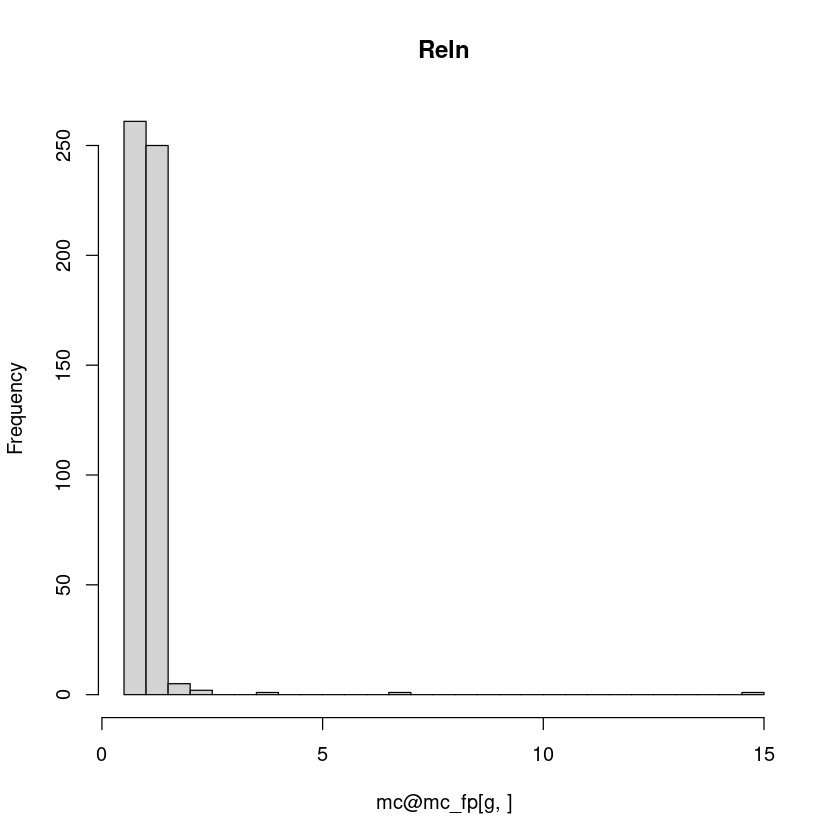

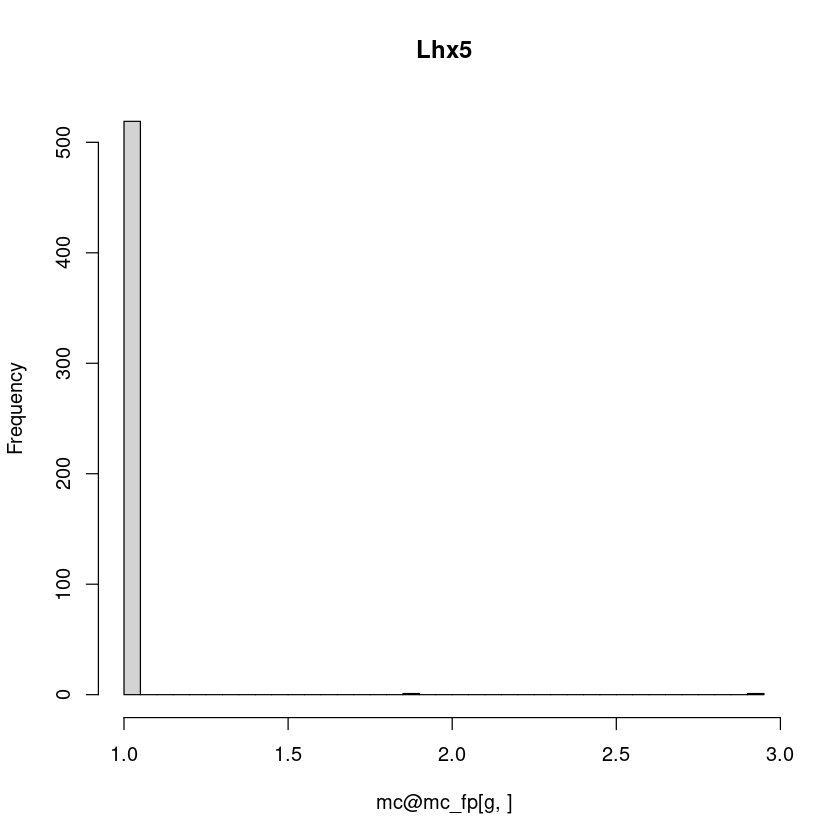

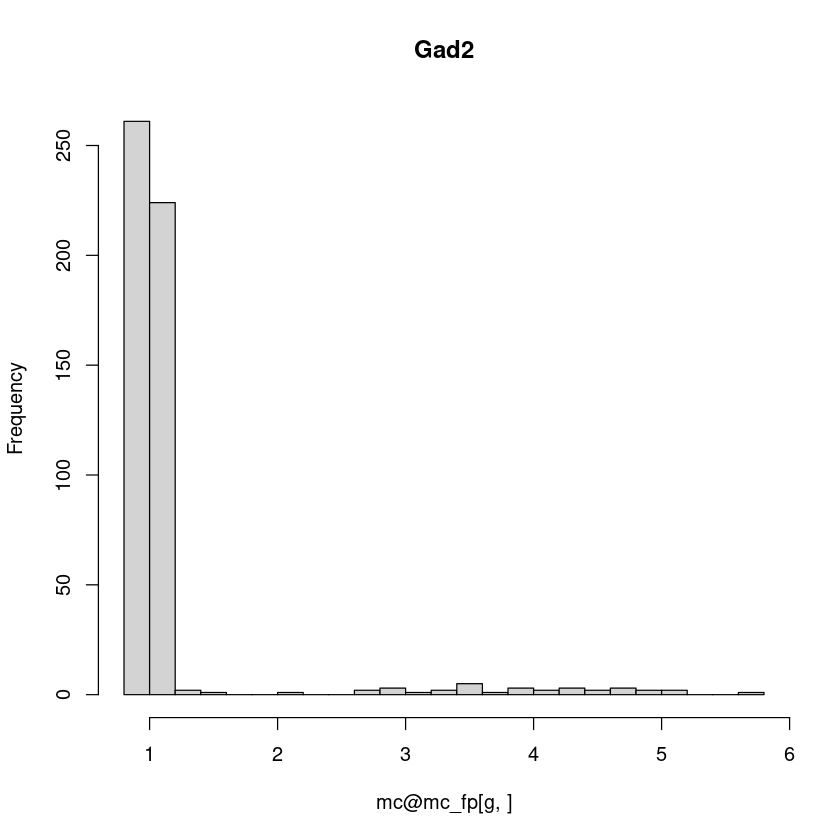

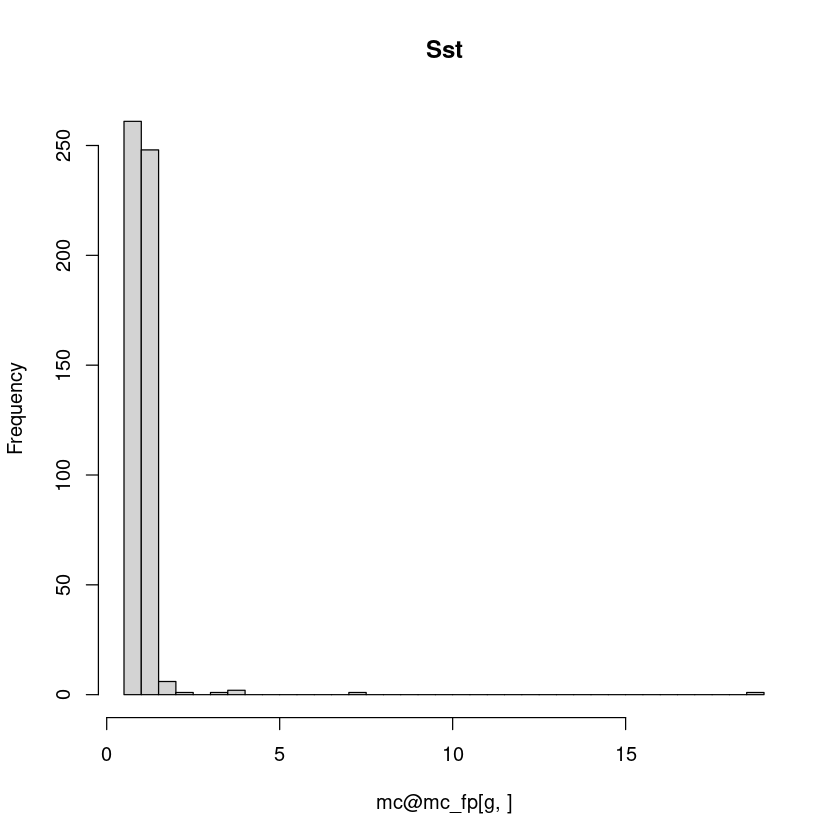

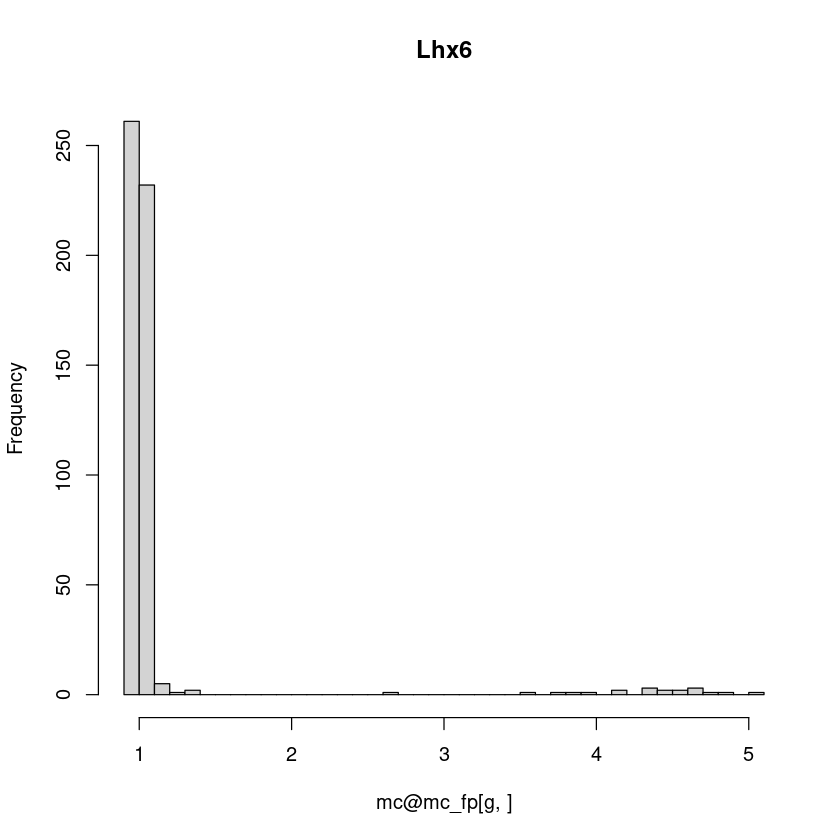

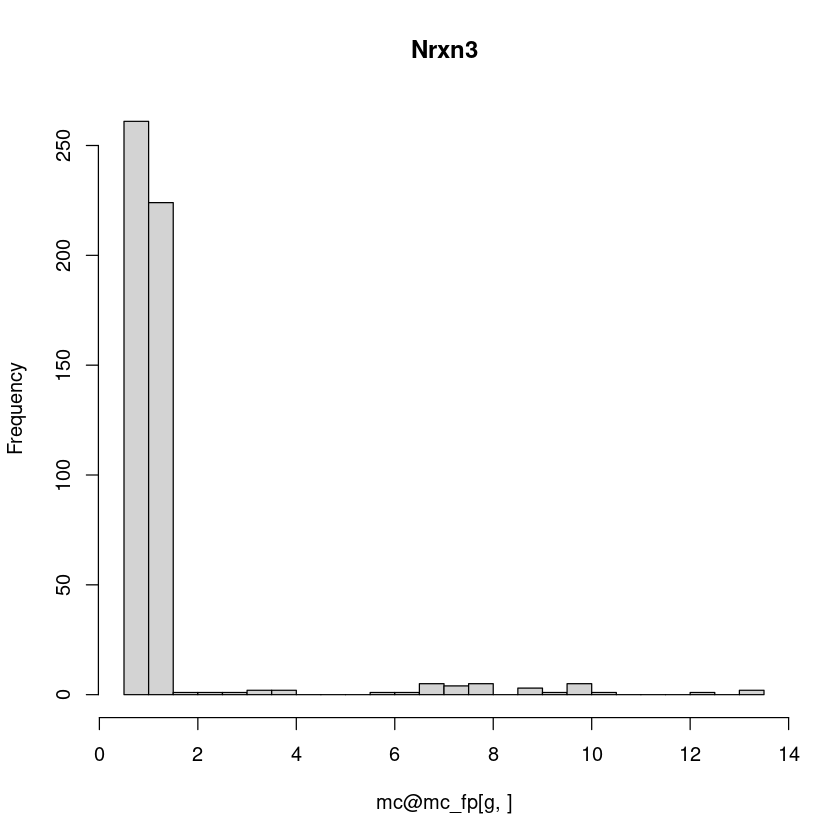

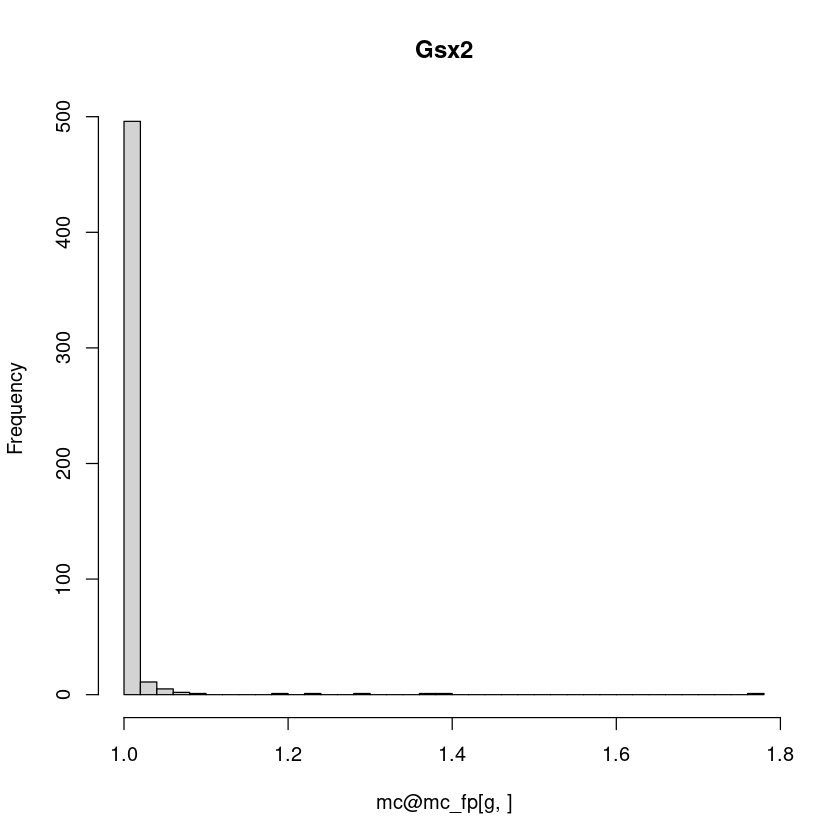

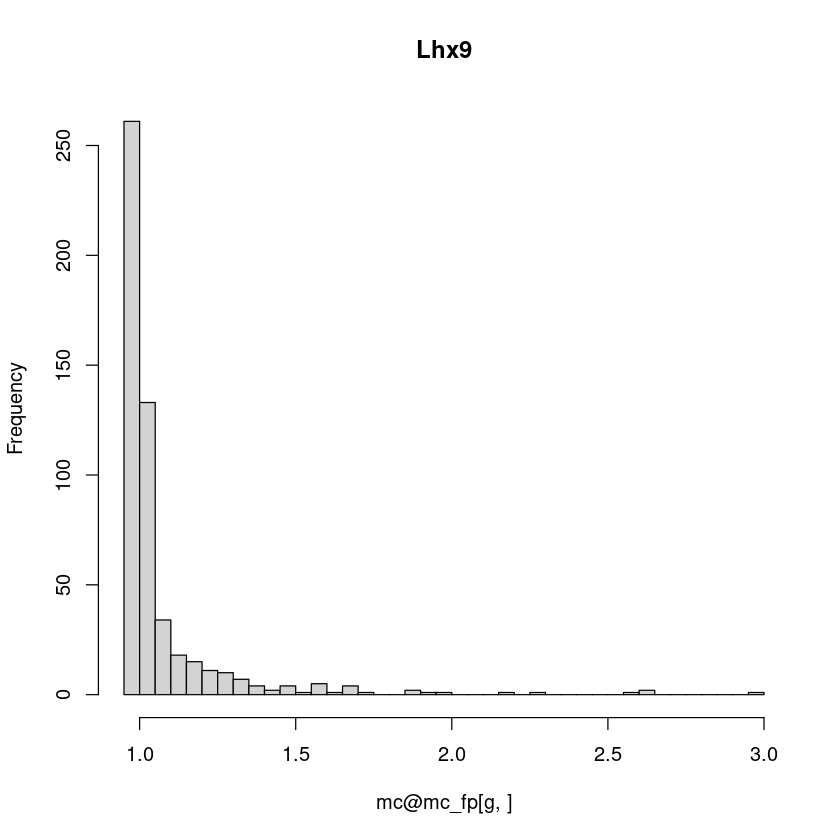

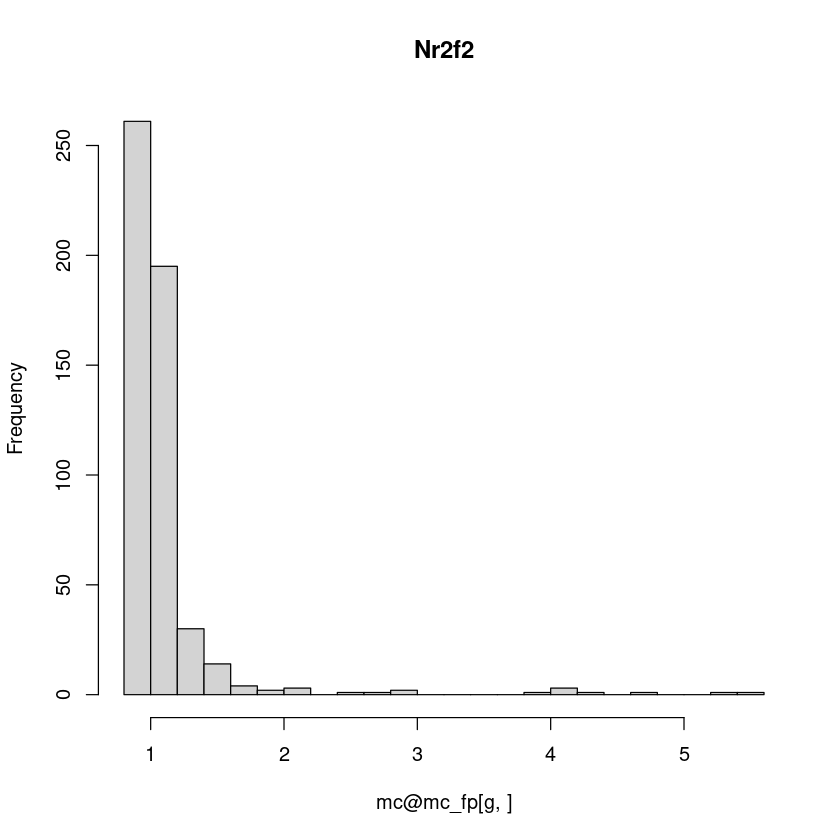

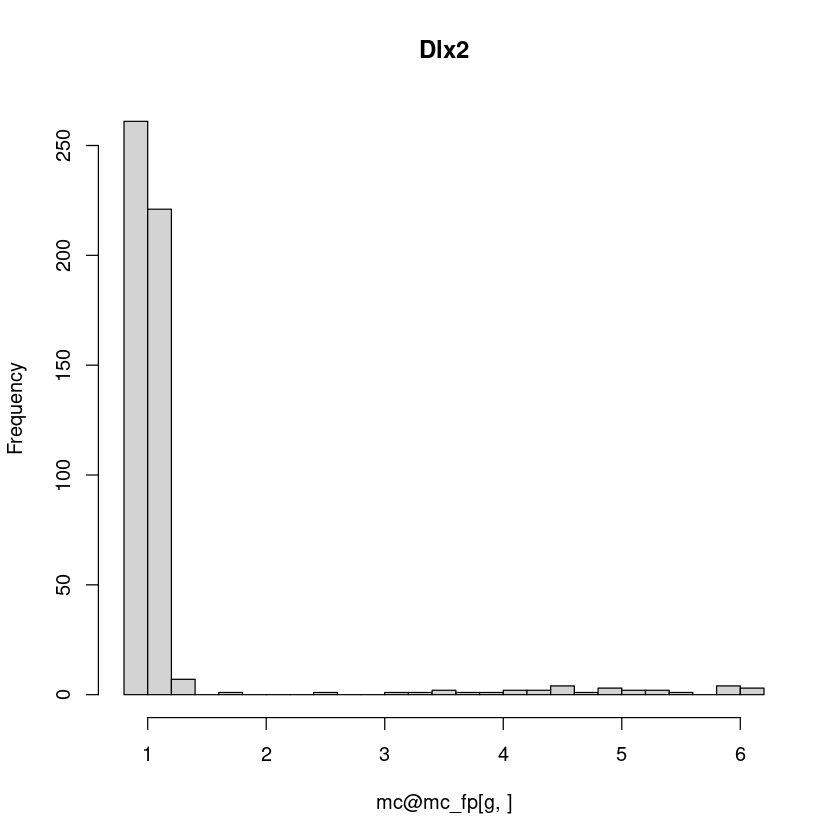

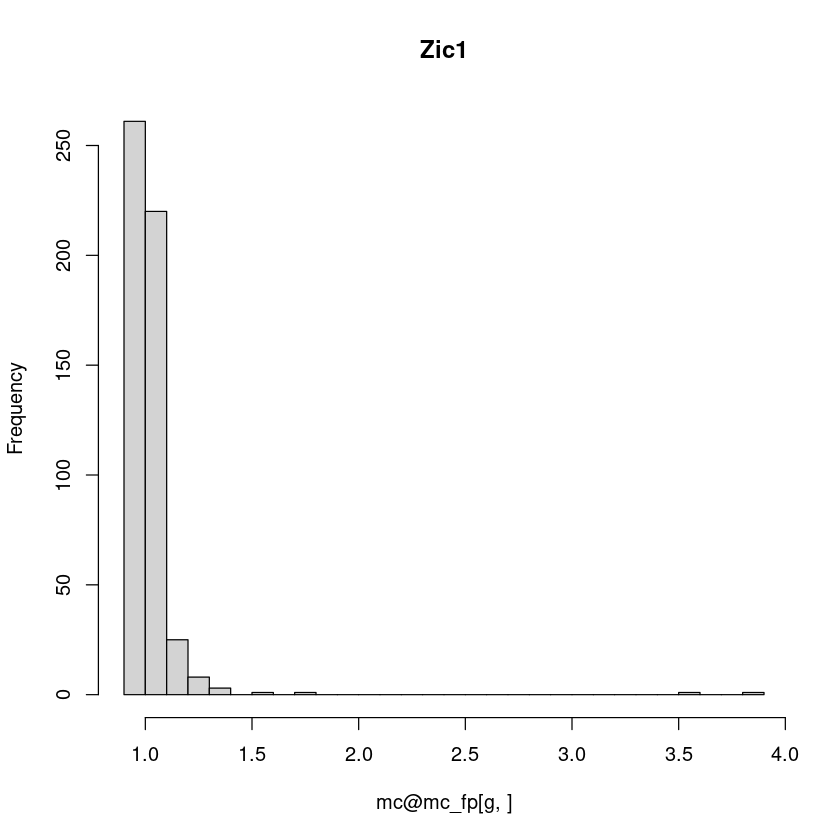

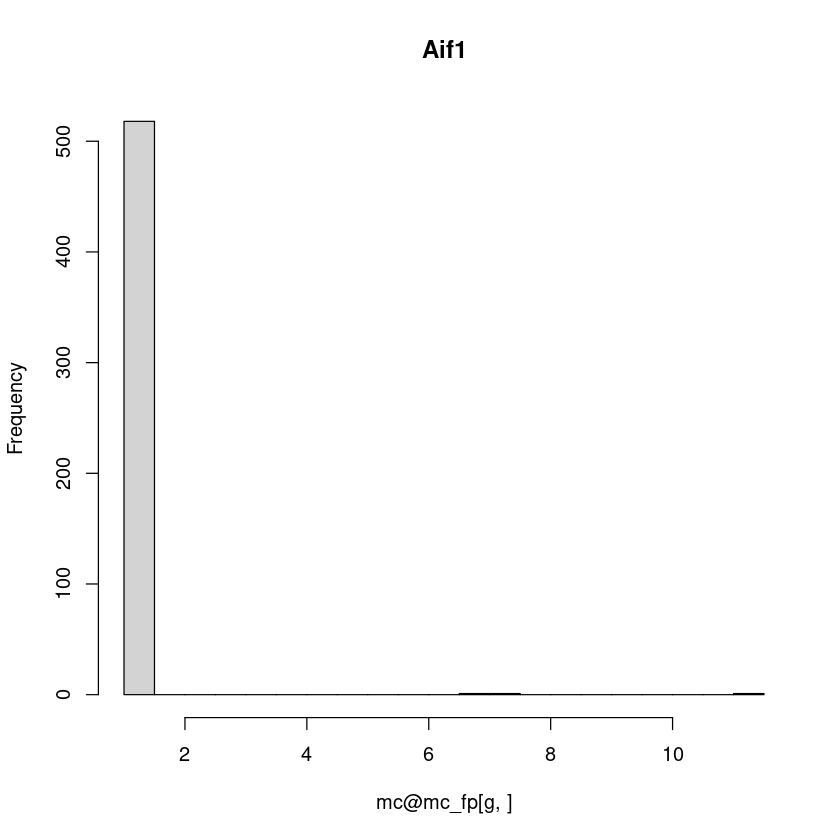

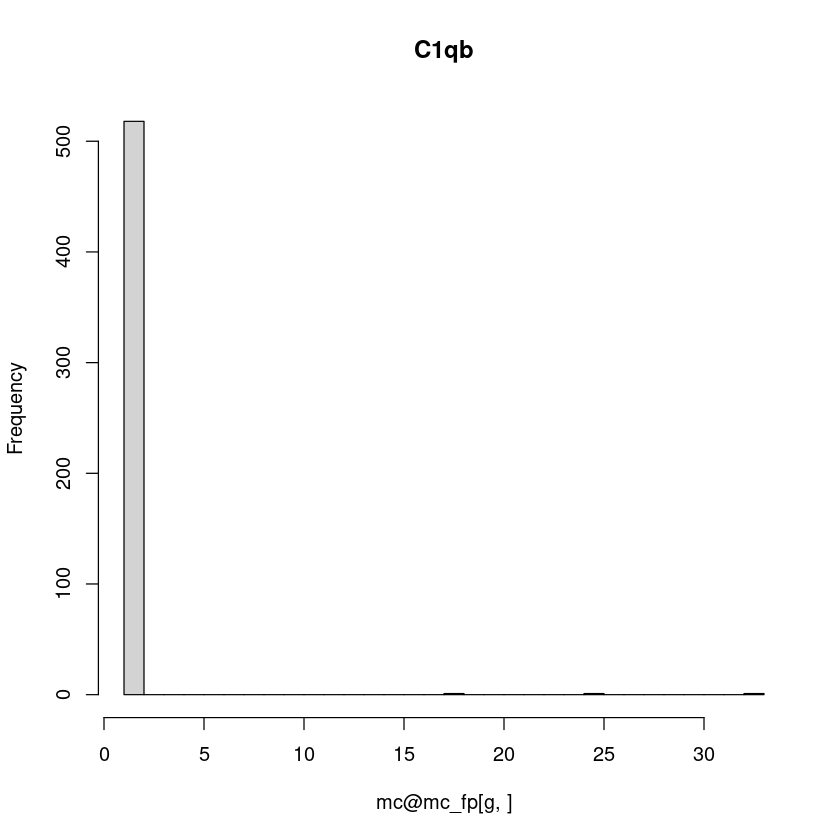

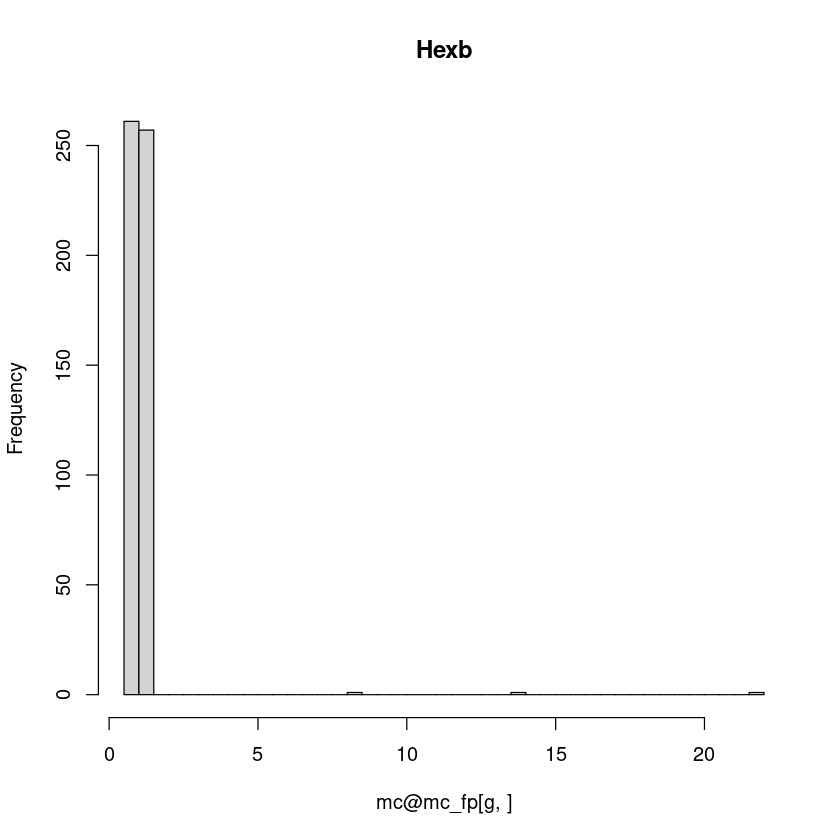

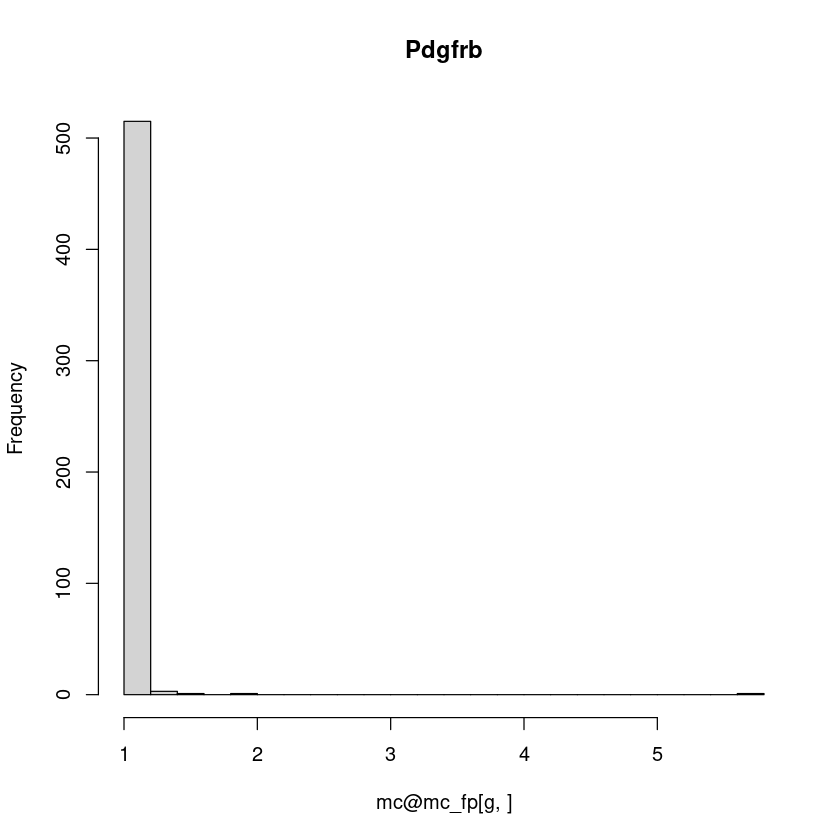

Reln                                                                                                                                                                                                                                                                                                                                                                                   
breaks   0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0                                                                                                                                                                                                                        
counts   261, 250, 5, 2, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1                                                                                                                                                                                                                                                                                              
density  1.001919386, 0.959692898, 0.019193858, 0.007677543, 0.000000000, 0.000000000, 0.003838772, 0.000000000, 0.000000000, 0.000000000, 0.000000000, 0.000000000, 0.003838772, 0.000000000, 0.000000000, 0.000000000, 0.000000000, 0.000000000, 0.000000000, 0.000000000, 0.000000000, 0.000000000, 0.000000000, 0.000000000, 0.000000000, 0.000000000, 0.000000000, 0.000000000, 0.003838772
mids     0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75, 5.25, 5.75, 6.25, 6.75, 7.25, 7.75, 8.25, 8.75, 9.25, 9.75, 10.25, 10.75, 11.25, 11.75, 12.25, 12.75, 13.25, 13.75, 14.25, 14.75                                                                                                                                                                                                 
xname    mc@mc_fp[g, ]                                                                                                                                                                                                                                                                                                                                                                          
equidist TRUE                                                                                                                                                                                                                                                                                                                                                                                   
         Lhx5                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
breaks   1.00, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35, 1.40, 1.45, 1.50, 1.55, 1.60, 1.65, 1.70, 1.75, 1.80, 1.85, 1.90, 1.95, 2.00, 2.05, 2.10, 2.15, 2.20, 2.25, 2.30, 2.35, 2.40, 2.45, 2.50, 2.55, 2.60, 2.65, 2.70, 2.75, 2.80, 2.85, 2.90, 2.95                                                                                                                                                                                                                                     
counts   519, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1                                                                                                                                                                                                                                          

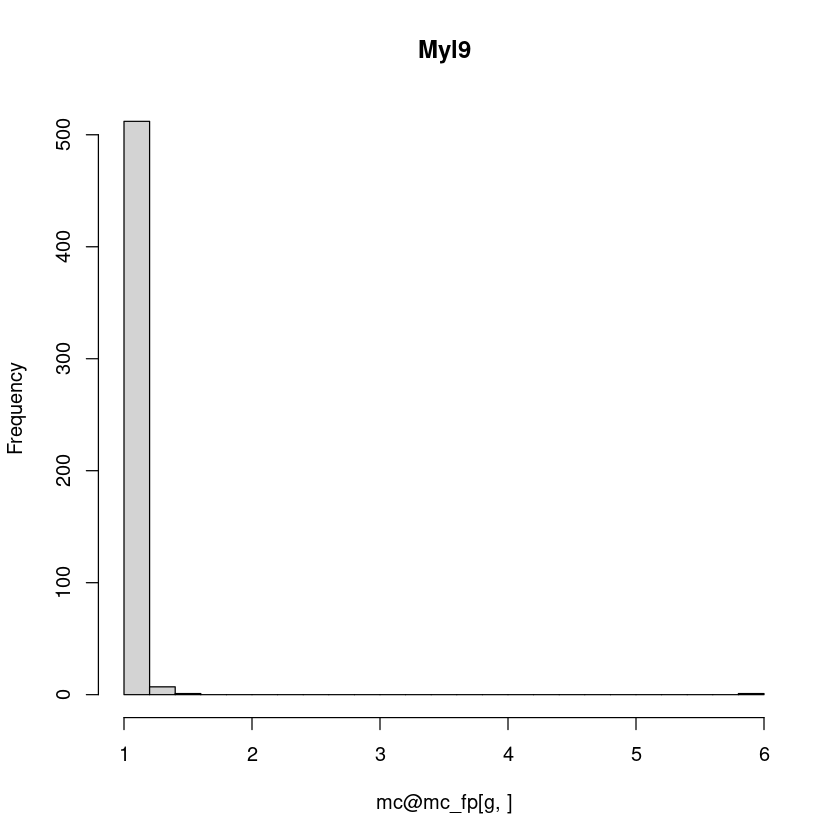

In [41]:
sapply(non_cort_genes, function(g) hist(mc@mc_fp[g,], 30, main = g))

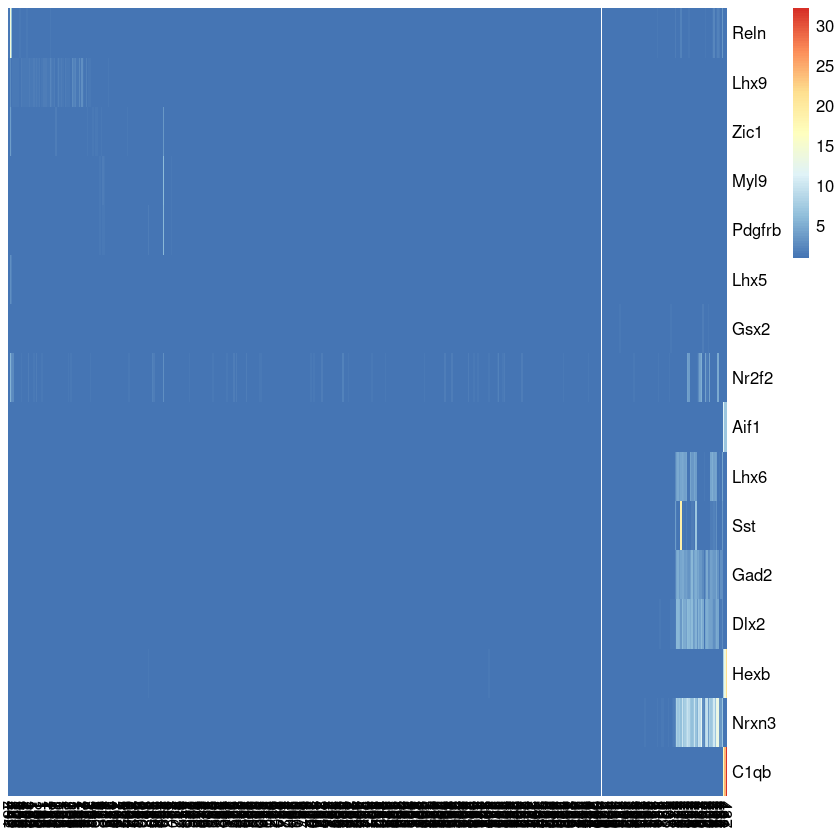

In [39]:
pheatmap::pheatmap(slanter::slanted_reorder(legcz_marks[non_cort_genes,]), cluster_rows = F, cluster_cols = F)

In [66]:
mcell_mc2d_plot_by_factor('pl', 'pl', meta_field = 'day', colors = rep('black', length(unique(mc@mc))))

png 
  2

In [67]:
mcell_mc2d_plot_by_factor('pl', 'pl', meta_field = 'day', single_plot = F, colors = rep('black', length(unique(mc@mc))))

In [26]:
groups(eg_louv)

$`1`
 [1] 16 17 18 19 20 21 22 25 42 43 44 45

$`2`
[1]   1   4   5   6  58  59  60  61 131

$`3`
 [1]  7  8  9 10 11 67 68 72 73 74 75 76 77 78 80 81 82 83 87 88 89 96 97

$`4`
 [1]  63  64  65  66  69  70  71  84  85  86  90  91  92  93  94  95  98  99 100
[20] 101 102

$`5`
 [1] 12 13 14 15 29 30 31 32 33 34 35 36 37 38 39 40 41 46 48 49 50 51 52 53 54
[26] 55 56 57 79

$`6`
 [1]   2   3  23  24  26  27  28  62 122 127 128 129 130 132 133 134 135 136 137
[20] 138 140 141 142 143 144 147 193 199 200 211

$`7`
 [1] 103 104 105 156 163 164 165 166 167 168 175 176 177 178 179 181 182 183 184
[20] 185 186 187 188 189 225 239 240 241 242 243 247 248 249

$`8`
 [1]  47 106 107 109 110 111 112 113 114 115 116 117 118 119 120 121 123 124 125
[20] 126 146 148 149 150 151 152 153 154 155

$`9`
 [1] 108 145 157 158 159 160 161 162 169 170 171 172 173 174 190 191 192 194 195
[20] 196 197 198 201 202 203 204 205 206 207 208 209 210 212 213 214 250 251 252
[39] 253 254 258 260 261 262 264 265 266 270 271 272 273

$`10`
[1] 230 231

$`11`
 [1] 259 274 275 284 287 288 289 290 292 297 299 300 301 302 305 306 307 308 309
[20] 310 311 312 313 315 316 318 319 355 359 387 391 473

$`12`
 [1] 233 235 244 245 246 267 268 269 276 277 278 279 280 281 285 286

$`13`
 [1] 232 255 256 257 263 282 283 291 293 294 295 296 298 314 317 320 321 322 323
[20] 324 325 326 329 356 364 365 366 367 368 369 370 371 372 373 374 375 380 384
[39] 385 386 388 389 390 392 393 394 395 396 397 398 399 400 401 402 403 404 405

$`14`
 [1] 406 407 408 409 410 411 412 413 414 415 417 418 419 420 421 422 423 424 425

$`15`
 [1] 426 427 428 429 430 431 432 433 434 435 436

$`16`
[1] 139 437 438 439 440 441

$`17`
 [1] 327 328 330 331 332 333 334 335 336 337 338 340 341 342 343 344 345 346 347
[20] 348 349 351 360 361 363 376 377 379 381 382 383 444 451 452 453 454 455 456
[39] 457 458 459 460 461 462 463 464

$`18`
 [1] 339 350 378 416 442 443 445 446 447 448 450 465 466 467 468 469 470 471 472
[20] 493 495 507

$`19`
 [1] 449 476 477 478 479 480 481 482 483 484 485 486 487 488 489 490 491 492 494
[20] 497 500 501 502 503 504 505 506

$`20`
 [1] 180 215 216 217 218 219 220 221 222 223 224 226 227 228 229 234 236 237 238
[20] 303 304 352 353 354 357 358 362 474 475 496 498 499 508 509 510 511 512 513
[39] 514 515 516 517 518 519 520 521

In [24]:
manual_colors = manual_colors[order(as.numeric(names(manual_colors)))]
manual_colors

1                2                3                4 
       "purple3"     "lightcyan2"     "lightcyan2"        "purple3" 
               5                6                7                8 
       "purple3"        "purple3"         "green3"         "green3" 
               9               10               11               12 
        "green3"         "green3"         "green3"  "darkgoldenrod" 
              13               14               15               16 
 "darkgoldenrod"  "darkgoldenrod"  "darkgoldenrod"          "azure" 
              17               18               19               20 
         "azure"          "azure"          "azure"          "azure" 
              21               22               23               24 
         "azure"          "azure"     "lightcyan2"     "lightcyan2" 
              25               26               27               28 
         "azure"     "lightcyan2"     "lightcyan2"     "lightcyan2" 
              29               30               31               32 
 "darkgoldenrod"  "darkgoldenrod"  "darkgoldenrod"  "darkgoldenrod" 
              33               34               35               36 
 "darkgoldenrod"  "darkgoldenrod"  "darkgoldenrod"  "darkgoldenrod" 
              37               38               39               40 
 "darkgoldenrod"  "darkgoldenrod"  "darkgoldenrod"  "darkgoldenrod" 
              41               42               43               44 
 "darkgoldenrod"          "azure"          "azure"          "azure" 
              45               46               47               48 
         "azure"  "darkgoldenrod"     "royalblue3"  "darkgoldenrod" 
              49               50               51               52 
 "darkgoldenrod"  "darkgoldenrod"  "darkgoldenrod"  "darkgoldenrod" 
              53               54               55               56 
 "darkgoldenrod"  "darkgoldenrod"  "darkgoldenrod"  "darkgoldenrod" 
              57               58               59               60 
 "darkgoldenrod"        "purple3"        "purple3"        "purple3" 
              61               62               63               64 
       "purple3"     "lightcyan2"          "beige"          "beige" 
              65               66               67               68 
         "beige"          "beige"         "green3"         "green3" 
              69               70               71               72 
         "beige"          "beige"          "beige"         "green3" 
              73               74               75               76 
        "green3"         "green3"         "green3"         "green3" 
              77               78               79               80 
        "green3"         "green3"  "darkgoldenrod"         "green3" 
              81               82               83               84 
        "green3"         "green3"         "green3"          "beige" 
              85               86               87               88 
         "beige"          "beige"         "green3"         "green3" 
              89               90               91               92 
        "green3"          "beige"          "beige"          "beige" 
              93               94               95               96 
         "beige"          "beige"          "beige"         "green3" 
              97               98               99              100 
        "green3"          "beige"          "beige"          "beige" 
             101              102              103              104 
         "beige"          "beige"    "aquamarine2"    "aquamarine2" 
             105              106              107              108 
   "aquamarine2"     "royalblue3"     "royalblue3" "lavenderblush2" 
             109              110              111              112 
    "royalblue3"     "royalblue3"     "royalblue3"     "royalblue3" 
             113              114              115              116 
    "royalblue3"     "royalblue3"     "royalblue3"     "royalblue3" 
             

In [74]:
mcell_mc2d_plot('pl')

png 
  2

In [25]:
mcell_mc2d_plot('pl', fn_suf = '_test_manual_colors', colors = manual_colors)

png 
  2

In [63]:
sapply(names(marks@gene_set), function(g) mcell_mc2d_plot_gene('pl', g))

Olig1.png     Olig2.png      Egr1.png    Pdgfra.png    Ptprz1.png 
            2             2             2             2             2 
     Apoe.png      Cst3.png     Sparc.png       Pbk.png    Nucks1.png 
            2             2             2             2             2 
    Ccnd2.png      Tmpo.png Hist1h2ap.png  Hist1h1b.png Hist1h2ae.png 
            2             2             2             2             2 
    Spc24.png       Mt1.png       Mt3.png     Ddah1.png     Fabp7.png 
            2             2             2             2             2 
    Phgdh.png     Aldoc.png       Ptn.png      Xist.png   Gadd45g.png 
            2             2             2             2             2 
  Neurog2.png      Btg2.png      Chd7.png       Ezr.png     Eomes.png 
            2             2             2             2             2 
   Rps15a.png     Cald1.png      Cdk6.png Arhgap11a.png       Mdk.png 
            2             2             2             2             2 
    Igsf8.png      Lhx2.png     Mfap4.png      Nrn1.png   Neurod1.png 
            2             2             2             2             2 
    Sstr2.png    Cdkn1c.png     Nhlh2.png   Neurod6.png      Rnd2.png 
            2             2             2             2             2 
      Pam.png    Cxcl12.png     Cntn2.png   Gm26917.png   Neurod2.png 
            2             2             2             2             2 
   Sema6d.png     Sox11.png      Pcp4.png     Unc5d.png    Zbtb20.png 
            2             2             2             2             2 
  Igfbpl1.png   Gm42418.png  AY036118.png      Nrp1.png    Pdzrn3.png 
            2             2             2             2             2 
     Sox4.png     Meis2.png    Sema3c.png    Pou3f1.png    Frmd4b.png 
            2             2             2             2             2 
    Lsamp.png      Cdh4.png     Nr2f1.png     Ttc28.png   Bhlhe22.png 
            2             2             2             2             2 
    Gpm6a.png     Basp1.png      Cnr1.png     Satb2.png    Tmsb4x.png 
            2             2             2             2             2 
  Gm17750.png     Gria2.png    Hs6st2.png     Myt1l.png    Frmd4a.png 
            2             2             2             2             2 
    Igsf3.png     Cd24a.png    Pou3f2.png    Pantr1.png       Arx.png 
            2             2             2             2             2 
      Dcx.png       Ubb.png       Maf.png       Sp9.png       Npy.png 
            2             2             2             2             2 
     Nnat.png      Mafb.png       Sst.png     Lars2.png     Nrxn3.png 
            2             2             2             2             2 
     Dlx1.png   Dlx6os1.png    Adarb2.png    Arpc1b.png      Pbx3.png 
            2             2             2             2             2 
    Zfhx3.png       B2m.png      Ctsd.png      Lgmn.png      Reln.png 
            2             2             2             2             2 
   Col4a1.png     Cldn5.png    Igfbp7.png     Gap43.png    Tubb2a.png 
            2             2             2             2             2 
    Tubb3.png     Stmn2.png      Mapt.png      Ly6h.png     Stmn4.png 
            2             2             2             2             2 
      Nts.png     Tenm2.png     Mef2c.png      Syt4.png     Ncam1.png 
            2             2             2             2             2 
    Foxp1.png     Ptprd.png       Ntm.png   Runx1t1.png     Opcml.png 
            2             2             2             2             2 
     Rtn1.png      Rprm.png    Pik3r1.png      Meg3.png       Ina.png 
            2             2             2             2             2 
    Foxp2.png     Nrxn1.png    Hs3st4.png     Cadm1.png     Celf2.png 
            2             2             2             2             2 
    Ssbp2.png    Grin2b.png    Arpp21.png    Hivep2.png    Bcl11b.png 
            2             2             2             2             2 
    Islr2.png      Sox5.png 

In [313]:
tgs_cor(t(log2(mc@e_gc[c('Dlx1', 'Dlx2', 'Dlx5','Lhx6', 'Gad2',  'Gad1', 'Zic1','Eomes', 'Pou3f2'),]+1e-07)), spearman = T)

,Dlx1,Dlx2,Dlx5,Lhx6,Gad2,Gad1,Zic1,Eomes,Pou3f2
Dlx1,1.000000000,0.7146898,0.50481662,0.3209477,0.743933566,0.57998230,0.04968397,-0.097637640,-0.007559133
Dlx2,0.714689809,1.0000000,0.58775839,0.2327062,0.735508060,0.55400843,0.13694025,-0.057259300,-0.145489304
Dlx5,0.504816624,0.5877584,1.00000000,0.2229889,0.567728946,0.47392635,0.13117889,0.025681453,-0.199978040
Lhx6,0.320947717,0.2327062,0.22298892,1.0000000,0.418987874,0.48502391,-0.35478391,-0.237280732,0.351360716
Gad2,0.743933566,0.7355081,0.56772895,0.4189879,1.000000000,0.64123443,0.03027549,-0.004089572,0.048521085
Gad1,0.579982302,0.5540084,0.47392635,0.4850239,0.641234430,1.00000000,-0.10590525,-0.120185763,0.080708349
Zic1,0.049683970,0.1369402,0.13117889,-0.3547839,0.030275490,-0.10590525,1.00000000,0.404850428,-0.184795059
Eomes,-0.097637640,-0.0572593,0.02568145,-0.2372807,-0.004089572,-0.12018576,0.40485043,1.000000000,0.180195726
Pou3f2,-0.007559133,-0.1454893,-0.19997804,0.3513607,0.048521085,0.08070835,-0.18479506,0.180195726,1.000000000


In [391]:
mcs_non_cort

[1]  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97
[20] 121 128 326 328 329 330 331 332 339 340 341 342 343 344 345 346 347 348 349
[39] 352 353 354 357 358 361 363 364 365 366 367 368 369 370 371 373 374 375 378
[58] 380 382 383

In [415]:
cells_non_cort = names(mc@mc)[mc@mc %in% as.numeric(unique(c(mcs_non_cort, bad_mcs)))]
length(cells_non_cort)

[1] 14310

In [393]:
length(mc@mc)

[1] 58037

In [432]:
bad_mcs

numeric(0)

In [417]:
length(mat@ignore_cells)

[1] 28485

In [418]:
mcs_non_cort = union(mcs_non_cort, bad_mcs)

non_cort_cells = names(mc@mc)[mc@mc %in% mcs_non_cort]

In [419]:
cells_ignore_new = union(non_cort_cells, mat@ignore_cells)
length(cells_ignore_new)

[1] 42795

In [ ]:
nm_new = paste0(nm, '_cort')
mcell_mat_ignore_cells(new_mat_id = nm_new, mat_id = nm, ig_cells = cells_ignore_new, reverse = F)

In [422]:
mg_mcs = which(top_3_st[1,] == 'Microglia')

In [426]:
sort(mc@mc_fp['Olig1',mcs_non_cort])

79        83        84        86        87        88        94        95 
 1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000 
      128       340       341       342       343       344       345       347 
 1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000 
      348       349       354       357       358       361       363       364 
 1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000 
      365       366       367       368       369       371       373       374 
 1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000 
      375       378       380       382        11       442       322       163 
 1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000 
      441       321       418       123       266       129       379       132 
 1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000 
      350       313       302       352       397        81        85       383 
 1.000000  1.003787  1.004813  1.004838  1.005173  1.005510  1.005898  1.005961 
      403       370       419        89       436       346       331       300 
 1.006553  1.006810  1.006919  1.007215  1.008093  1.008602  1.008625  1.008734 
        7       320       339       161       353       122        93        96 
 1.009298  1.009963  1.012142  1.012472  1.013167  1.013271  1.013736  1.014075 
      173        97        82       158        80       444       306       296 
 1.016167  1.016970  1.017773  1.019239  1.021717  1.021802  1.022740  1.023749 
      326        91        90       329       308       330       312       299 
 1.024382  1.027155  1.027420  1.031535  1.032210  1.034096  1.035241  1.035723 
      297        92       332       327       309       298       121       130 
 1.039468  1.044168  1.046147  1.081348  1.088041  1.088137  1.091996  1.099603 
      305       131       233       307       328       232       234       285 
 1.105229  1.106974  1.130836  1.157977  1.217991  1.319657  2.603695  2.715893 
      237       351 
 2.818597 18.451097

In [427]:
top_3_st[,351]

[1] "Oligodendrocytes" "IN_CGE"           "NSC"

In [424]:
mc@mc_fp['Olig2',mg_mcs]

[1] 1.007977

In [421]:
# mc@mc_fp[c('Dlx1', 'Dlx2', 'Dlx5','Lhx6', 'Gad2',  'Gad1', 'Zic1'),
ge_genes = c('Dlx1', 'Dlx2', 'Dlx5','Lhx6', 'Gad2',  'Gad1', 'Nrxn3')
ge_marks_in_cort = sort(apply(t(mc@mc_fp[ge_genes,!(1:ncol(mc@mc_fp) %in% mcs_non_cort)]), 1, max))         
ge_marks_in_cort
bad_mcs = as.numeric(names(ge_marks_in_cort[ge_marks_in_cort >= 1.1]))
bad_mcs
t(mc@mc_fp[ge_genes,bad_mcs])
#         ]

71       100       133       137       146       147       153       154 
0.9930809 0.9930809 0.9930809 0.9930809 0.9930809 0.9930809 0.9930809 0.9930809 
      249       270       150       267        73       406       138       277 
0.9930809 0.9930809 0.9934570 0.9942099 0.9942184 0.9943303 0.9943622 0.9944793 
      250       445       244       387       272       108        98       141 
0.9946471 0.9951237 0.9952124 0.9953147 0.9954078 0.9956353 0.9957775 0.9957999 
      245       428       143       111        66        75       271       229 
0.9959568 0.9961052 0.9963314 0.9963926 0.9964782 0.9965748 0.9966536 0.9968733 
      288       433       248       186       134       257       430       425 
0.9969002 0.9970375 0.9970738 0.9971065 0.9972359 0.9972369 0.9973672 0.9973724 
      385        45       136       407       278       276       109        69 
0.9974114 0.9977434 0.9978633 0.9979988 0.9979999 0.9980793 0.9980894 0.9981061 
      247       145       115       152       149       105       139       217 
0.9981755 0.9982015 0.9982226 0.9982694 0.9983453 0.9985256 0.9989413 0.9989682 
      432       254       189       319         2       246       103        70 
0.9990716 0.9991109 0.9992720 0.9993245 0.9994056 0.9994363 0.9995095 0.9995573 
      219        72        62       107       437       412        99        67 
0.9995905 0.9998075 0.9998645 0.9998805 0.9999379 1.0000000 1.0001053 1.0002165 
      142       140       135       116       400       409       148       388 
1.0004235 1.0004885 1.0007022 1.0007840 1.0009087 1.0010793 1.0011376 1.0012482 
      253       151       268       280       386       144       211       338 
1.0016918 1.0018529 1.0022660 1.0022663 1.0023120 1.0026504 1.0026848 1.0027193 
      275       241       269       252       284       218        52       404 
1.0027762 1.0030663 1.0030685 1.0031063 1.0032734 1.0035069 1.0036509 1.0037444 
      316       220        63       274       240        77       193        44 
1.0038036 1.0038874 1.0041579 1.0041752 1.0041830 1.0042207 1.0042253 1.0042554 
       51       259        20       356       231        61       117       273 
1.0043077 1.0043774 1.0046213 1.0047207 1.0048412 1.0049340 1.0052207 1.0053365 
      188       216       261       104        74        25       283       255 
1.0053843 1.0054725 1.0055746 1.0056444 1.0056527 1.0057704 1.0058169 1.0059111 
       65       405       239       435       110        24       279        28 
1.0059184 1.0059409 1.0059636 1.0061674 1.0062515 1.0063224 1.0064196 1.0064694 
      185       424       410        23       411         1       376         8 
1.0065393 1.0065740 1.0065742 1.0067803 1.0070012 1.0071259 1.0075234 1.0075505 
       68       282       192       394       362        46        53       421 
1.0075969 1.0081404 1.0082135 1.0084221 1.0084845 1.0085350 1.0086473 1.0086806 
      314       157       393        26       213        27        57       286 
1.0089382 1.0089904 1.0091858 1.0094905 1.0095091 1.0096913 1.0099029 1.0102824 
       78       198        38       323        16       265       434        36 
1.0103015 1.0106073 1.0108030 1.0108050 1.0111094 1.0111708 1.0113195 1.0113370 
      242        55       408       446         9        56       187         3 
1.0115963 1.0117076 1.0119178 1.0122325 1.0122550 1.0123538 1.0130570 1.0132107 
       76       391       199       112       177       204        18        21 
1.0133819 1.0135563 1.0139217 1.0149585 1.0154206 1.0155963 1.0157293 1.0161571 
      183         6       281       337        19       106       221       263 
1.0161911 1.0162326 1.0164204 1.0169113 1.0170075 1.0171080 1.0173853 1.0177794 
      260       399       290         4       101       438       214       256 
1.0181101 1.0182695 1.0183394 1.0184078 1.0186227 1.0186876 1.0188708 1.0189387 
      238       287       317       251       202       291        15       392 
1.0190288 1.0190570 1.0191342 1.019206

numeric(0)

Dlx1,Dlx2,Dlx5,Lhx6,Gad2,Gad1,Nrxn3


In [413]:
mcell_mc2d_plot(nm, colors = ifelse(1:length(unique(mc@mc)) %in% bad_mcs, 'red', 'black'), fn_suf = '_test_bad_mcs')

png 
  2

In [405]:
top_3_st[,bad_mcs]

309,297,306,419,307,320,296,379,298,327
NSC,NSC,NSC,IPC,NSC,NSC,NSC,CthPN,NSC,IPC
NPC_GE,NPC_GE,NPC_GE,NPC_CGE,MSN,MSN,NPC_GE,IN_CGE,MSN,MSN
MSN,MSN,MSN,MSN,NPC_GE,PC,MSN,SCPN,NPC_GE,NPC_GE


In [315]:
feats = scdb_gset(paste0(nm, '_f'))
feats = names(feats@gene_set)

In [316]:
cor_feats = tgs_cor(t(mc@mc_fp[feats,]), spearman = T)

In [321]:
g = 'Dlx1'
head(cor_feats[g,order(cor_feats[g,], decreasing = T)], 20)

Dlx1      Gad2      Dlx2   Dlx6os1       Sp9     Nrxn3      Gad1   Slc32a1 
1.0000000 0.7439336 0.7146898 0.6982971 0.6895995 0.6543258 0.5799823 0.5787788 
     Gsx2   Zcchc12      Dlx6    Atp1b1    Slc6a1    Thsd7a      Dlx5    Snhg11 
0.5570983 0.5301546 0.5144361 0.5132696 0.5084930 0.5083978 0.5048166 0.4930714 
   Vstm2b      Six3     Ptch1    Ripor2 
0.4878149 0.4795106 0.4668325 0.4666159

In [321]:
g = 'Dlx1'
head(cor_feats[g,order(cor_feats[g,], decreasing = T)], 20)

Dlx1      Gad2      Dlx2   Dlx6os1       Sp9     Nrxn3      Gad1   Slc32a1 
1.0000000 0.7439336 0.7146898 0.6982971 0.6895995 0.6543258 0.5799823 0.5787788 
     Gsx2   Zcchc12      Dlx6    Atp1b1    Slc6a1    Thsd7a      Dlx5    Snhg11 
0.5570983 0.5301546 0.5144361 0.5132696 0.5084930 0.5083978 0.5048166 0.4930714 
   Vstm2b      Six3     Ptch1    Ripor2 
0.4878149 0.4795106 0.4668325 0.4666159

In [322]:
g = 'Gad2'
head(cor_feats[g,order(cor_feats[g,], decreasing = T)], 20)

Gad2          Dlx1         Nrxn3          Dlx2       Dlx6os1 
    1.0000000     0.7439336     0.7382255     0.7355081     0.7307004 
          Sp9          Gad1       Slc32a1          Dlx5        Thsd7a 
    0.7126896     0.6412344     0.5909567     0.5677289     0.5514563 
       Atp1b1        Slc6a1       Carhsp1         Nxph1        Ripor2 
    0.5482176     0.5422461     0.5362294     0.5292673     0.5238485 
         Dlx6         Erbb4        Snhg11       Zcchc12 C130073E24Rik 
    0.5179124     0.5148021     0.5141277     0.5121932     0.5002354

In [323]:
g = 'Lhx6'
head(cor_feats[g,order(cor_feats[g,], decreasing = T)], 20)

Lhx6       Npy   Gucy1a1     Mef2c   Pde4dip   Fam19a2      Chd5   Prkar1b 
1.0000000 0.7083415 0.6808501 0.6673867 0.6587418 0.6484129 0.6470747 0.6379086 
     Dnm3     Macf1    Hivep3     Erbb4   Smarca2   Dync1i1    Grin2b   Gm17750 
0.6263638 0.6238627 0.6194271 0.6178649 0.6149207 0.6147695 0.6103900 0.6101074 
   Trim67     Tmod2    Dlgap1     Reps2 
0.6100362 0.6041648 0.6027680 0.6017913

In [329]:
g = 'Nr2f2'
head(cor_feats[g,order(cor_feats[g,], decreasing = T)], 20)

Nr2f2    Slc6a1      Nrp2     Nr2f1     Cbln2      Ebf1     Rwdd3     Synpr 
1.0000000 0.5852725 0.5265024 0.5041840 0.4983434 0.4979131 0.4758564 0.4737727 
  Gm28050     Meis1      Fign   Carhsp1     Acer2      St18      Rgs2   Gm13404 
0.4637828 0.4615325 0.4576275 0.4484535 0.4393581 0.4288790 0.4264594 0.4248931 
     Nnat      Rem2      Pbx3     Rcan2 
0.4228281 0.4137517 0.4119530 0.4108166

In [330]:
g = 'Ebf1'
head(cor_feats[g,order(cor_feats[g,], decreasing = T)], 20)

Ebf1     Cbln2   Gm28050      Fign  Tmem176a   Gm13404      Isl1    Barhl2 
1.0000000 0.6658468 0.6578110 0.6366902 0.5803199 0.5759795 0.5701559 0.5696638 
  Cntnap2     Nhlh2      Rnd3    Btbd17     Rwdd3     Nhlh1     Ap3s1      Dll3 
0.5657789 0.5656751 0.5483797 0.5390899 0.5390582 0.5348819 0.5311462 0.5305344 
     Uncx  Tmem176b      Mfng   Gadd45a 
0.5302030 0.5297860 0.5262490 0.5254469

In [332]:
g = 'Slc6a1'
head(cor_feats[g,order(cor_feats[g,], decreasing = T)], 20)

Slc6a1       Carhsp1         Nr2f2         Nrxn3          Gad2 
    1.0000000     0.6410982     0.5852725     0.5587428     0.5422461 
         Pbx3         Rcan2          Dlx1      Cacna2d2          Meg3 
    0.5338605     0.5203384     0.5084930     0.5078948     0.5077172 
       Slc1a2       Dlx6os1         Meis1          Dlx2          Myt1 
    0.5025672     0.4961252     0.4910564     0.4850616     0.4834196 
          Sp9 2900060B14Rik         Prox1       Cbfa2t3 D030055H07Rik 
    0.4822960     0.4795368     0.4716518     0.4692458     0.4580096

In [337]:
goii = c('Slc6a1', 'Nrp2', 'Cbln2', 'Carhsp1', 'Gsx2')
sapply(goii, function(g) mcell_mc2d_plot_gene(nm, g))

Slc6a1.png    Nrp2.png   Cbln2.png Carhsp1.png    Gsx2.png 
          2           2           2           2           2

In [ ]:
mg_bon$marks[mg_bon$st == 'NPC_CGE']

In [65]:
legc = log2(mc@e_gc + 1e-07)
goi = c('Dlx1', 'Dlx2', 'Dlx5','Lhx6', 'Gad2',  'Gad1', 'Zic1')
cs = Matrix::colSums(mat@mat)
nnz_cells = sapply(goi, function(g) which(mat@mat[g,] > 0))
# sapply(goi, function(g) quantile(mat@mat[g,]/cs, c(seq(0,0.95,0.05),seq(0.96,0.99,0.01),0.999,1)))
# sapply(goi, function(g) hist(log2(mat@mat[g,]/cs + 1e-07), 50))
# hist(legc['Dlx1',], 50)

# hist(legc['Dlx2',], 50)

In [66]:
length(unique(unlist(nnz_cells)))

[1] 15232

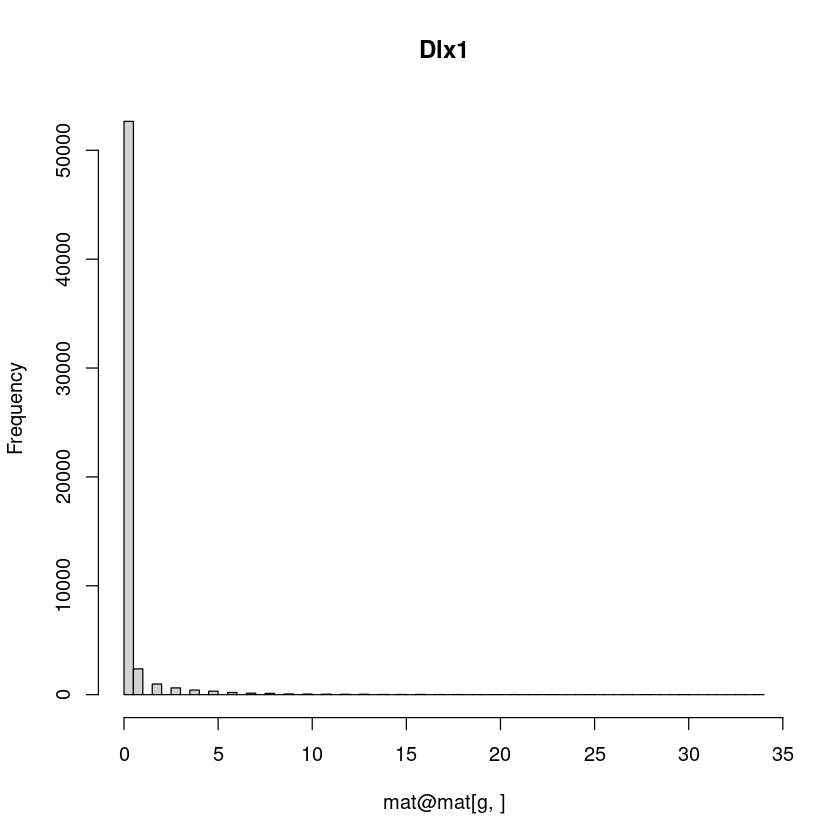

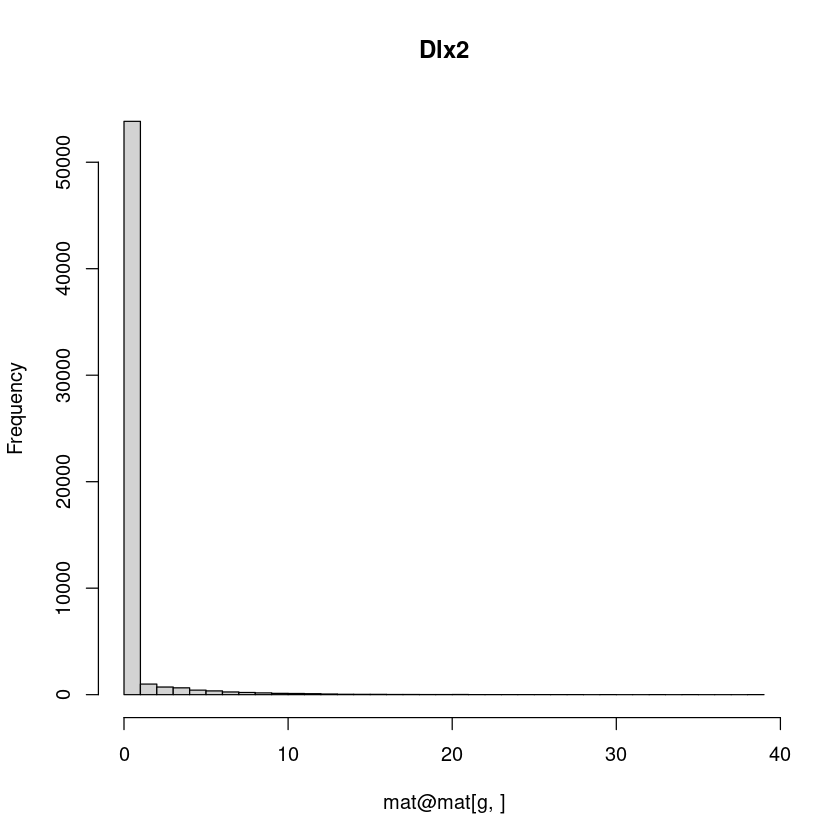

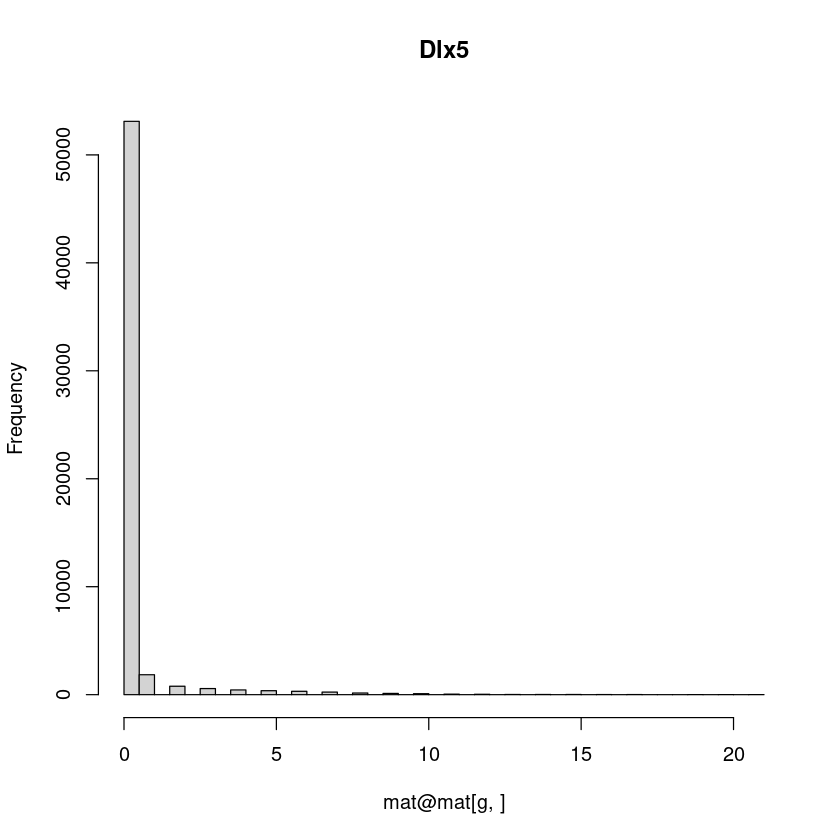

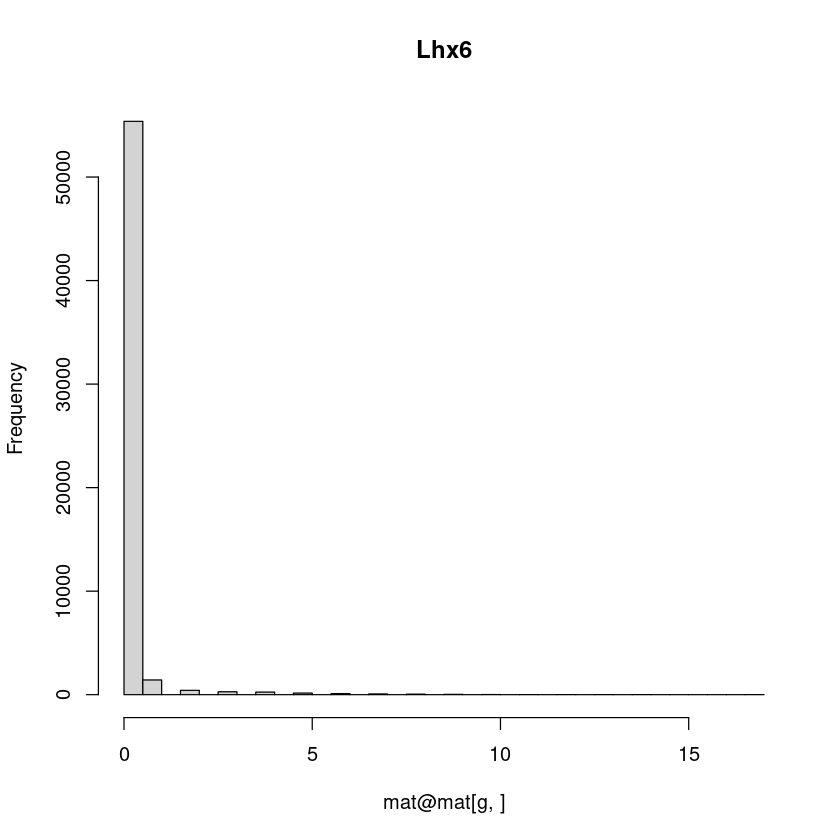

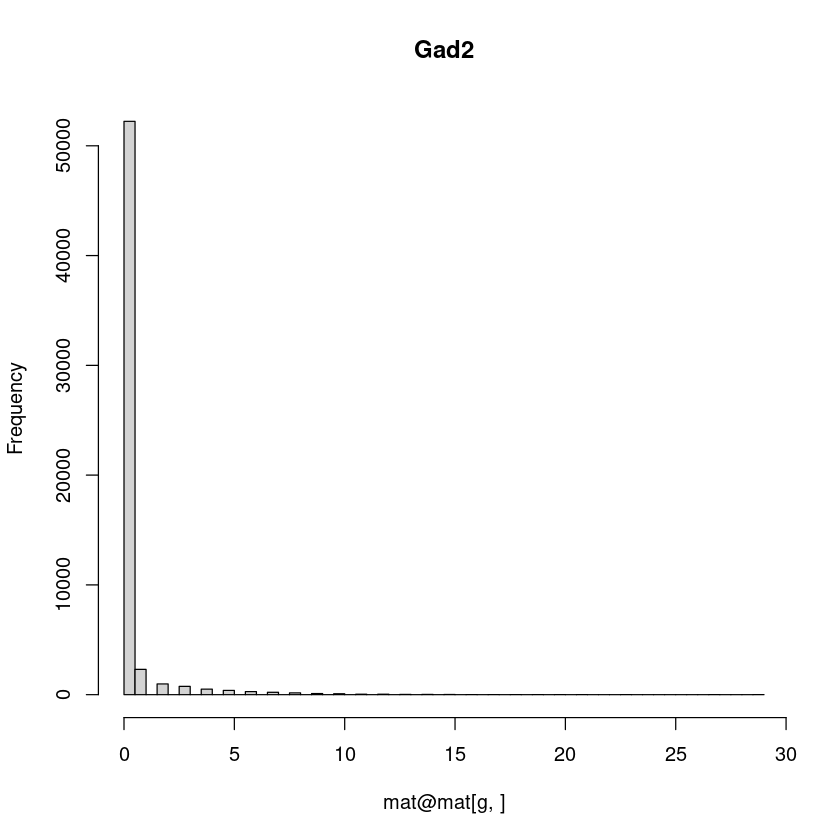

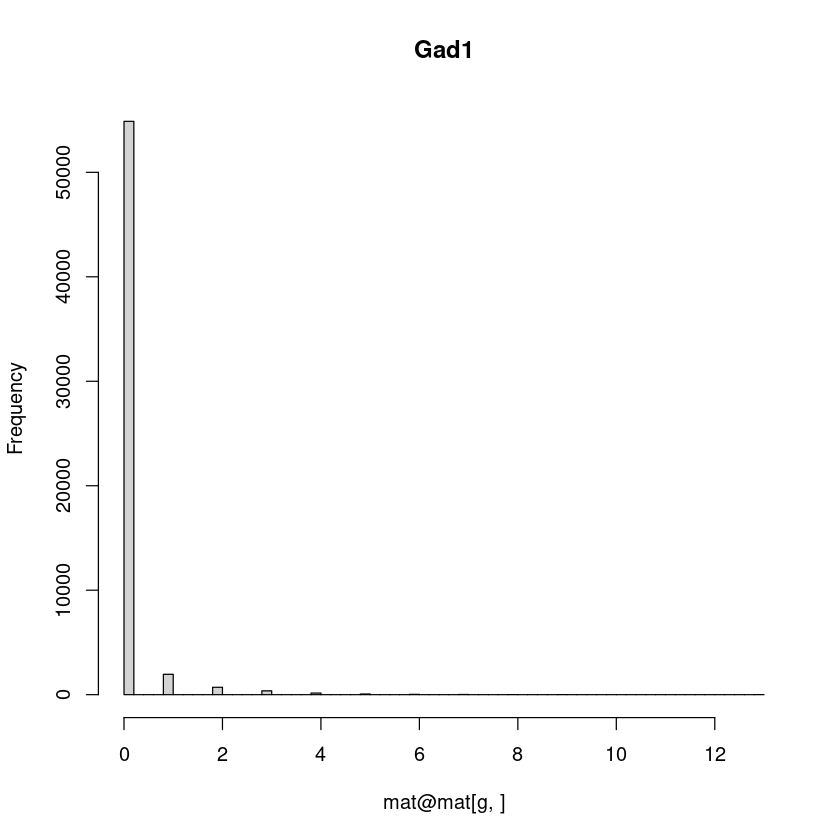

Dlx1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
breaks   0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0, 27.5, 28.0, 28.5, 29.0, 29.5, 30.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
counts   52659, 2368, 0, 975, 0, 623, 0, 423, 0, 319, 0, 198, 0, 132, 0, 123, 0, 67, 0, 55, 0, 47, 0, 36, 0, 42, 0, 18, 0, 18, 0, 24, 0, 9, 0, 12, 0, 4, 0, 2, 0, 10, 0, 1, 0, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
density  1.810365e+00, 8.140954e-02, 0.000000e+00, 3.351955e-02, 0.000000e+00, 2.141813e-02, 0.000000e+00, 1.454233e-02, 0.000000e+00, 1.096691e-02, 0.000000e+00, 6.807048e-03, 0.000000e+00, 4.538032e-03, 0.000000e+00, 4.228621e-03, 0.000000e+00, 2.303395e-03, 0.000000e+00, 1.890847e-03, 0.000000e+00, 1.615814e-03, 0.000000e+00, 1.237645e-03, 0.000000e+00, 1.443919e-03, 0.000000e+00, 6.188225e-04, 0.000000e+00, 6.188225e-04, 0.000000e+00, 8.250967e-04, 0.000000e+00, 3.094113e-04, 0.000000e+00, 4.125483e-04, 0.000000e+00, 1.375161e-04, 0.000000e+00, 6.875806e-05, 0.000000e+00, 3.437903e-04, 0.000000e+00, 3.437903e-05, 0.000000e+00, 1.375161e-04, 0.000000e+00, 0.000000e+00, 0.000000e+00, 3.437903e-05, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 6.875806e-05, 0.000000e+00, 0.000000e+00, 0.000000e+00, 3.437903e-05, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 6.875806e-05
mids     0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75, 5.25, 5.75, 6.25, 6.75, 7.25, 7.75, 8.25, 8.75, 9.25, 9.75, 10.25, 10.75, 11.25, 11.75, 12.25, 12.75

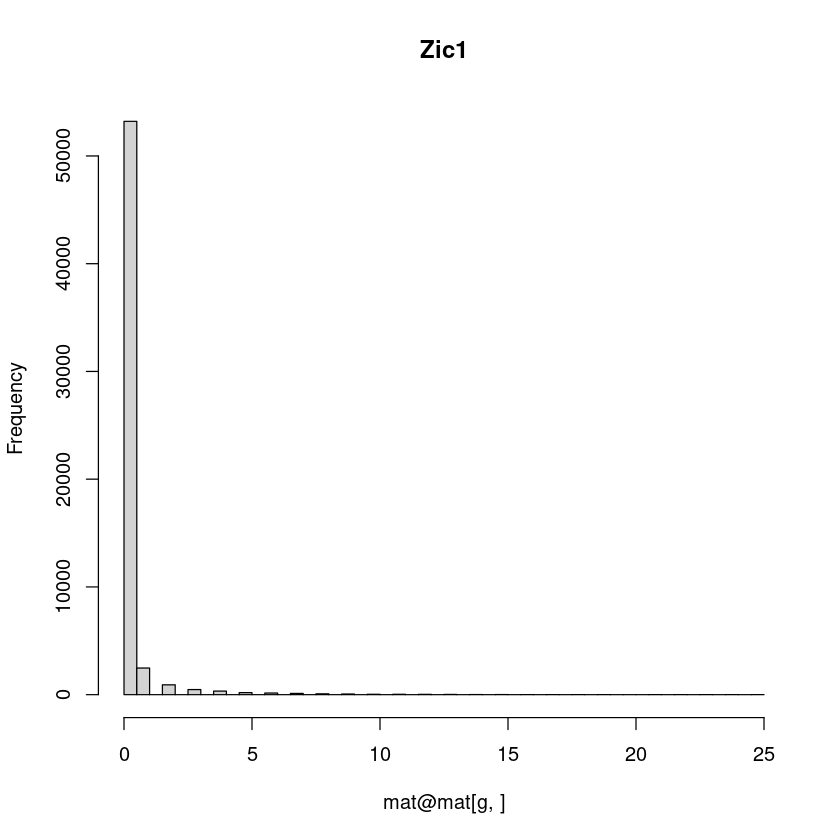

In [67]:
legc = log2(mc@e_gc + 1e-07)
goi = c('Dlx1', 'Dlx2', 'Dlx5','Lhx6', 'Gad2',  'Gad1', 'Zic1')
sapply(goi, function(g) hist(mat@mat[g,], 50, main=g))
# hist(legc['Dlx1',], 50)

# hist(legc['Dlx2',], 50)

### How to filter out NPC_(C)GE without filtering out iCPN

In [343]:
npc_ge_mc = which(top_3_st[1,] %in% c('NPC_GE'))

In [344]:
npc_cge_mc = which(top_3_st[1,] %in% c('NPC_CGE'))

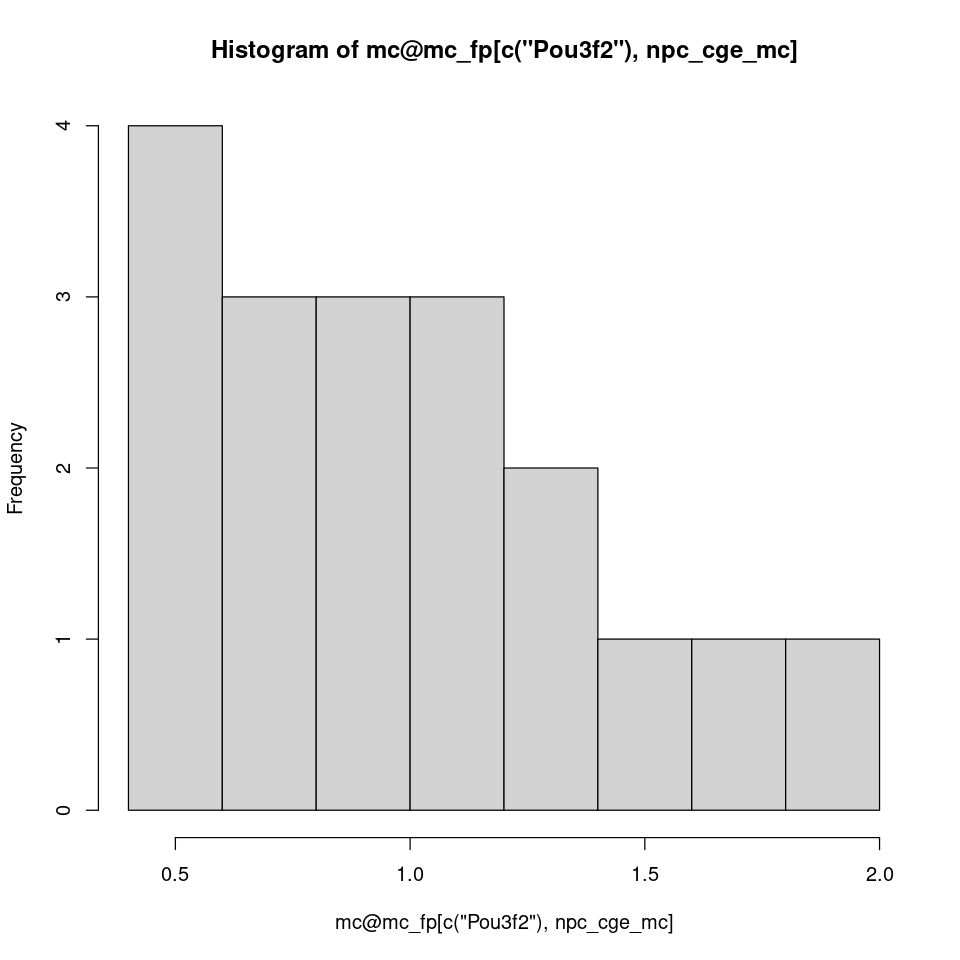

In [345]:
hist(mc@mc_fp[c('Pou3f2'),npc_cge_mc])

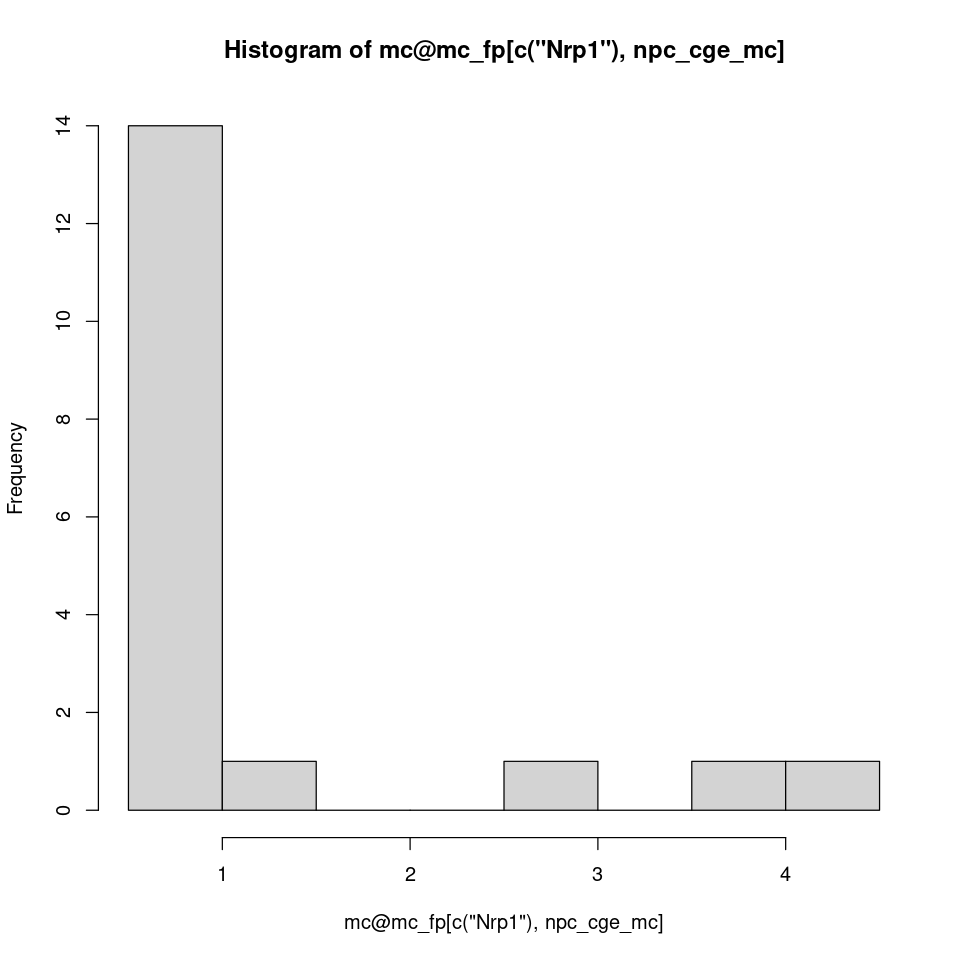

In [346]:
hist(mc@mc_fp[c('Nrp1'),npc_cge_mc])

In [354]:
npc_ge_marks_mat = t(mc@mc_fp[c('Pou3f2', 'Rnd2', 'Sstr2', 'Nrp1', 'Dlx1','Dlx2', 'Gsx2', 'Lhx9'),npc_mc])

In [370]:
sort(legcz_marks[,128], decreasing = T)

Nrxn3     Satb2      Cux2      Ldb2    Bcl11b       Sst      Lhx6      Gad2 
4.1829290 2.9636944 2.0900987 1.5033966 1.4831289 1.4088004 1.3372827 1.2681164 
     Sox5      Dlx2      Reln       Lpl     Nr2f2   Aldh1l1      Rorb      Cux1 
1.2660844 1.2130441 1.2046953 1.1935940 1.1807757 1.1741946 1.1692943 1.1160683 
     Apoe    Pdgfra      Tle4      Gas1    Pou3f2      Hexb      Hes1      Aif1 
1.1129012 1.0916347 1.0834557 1.0565731 1.0544019 1.0475778 1.0252396 1.0000000 
     C1qb      Gfap      Gsx2      Lhx5     Olig1    Pdgfrb      Myl9     Olig2 
1.0000000 1.0000000 1.0000000 1.0000000 1.0000000 1.0000000 0.9974238 0.9966756 
      Id4      Lhx9      Zic1   Neurog2     Eomes     Fezf2      Pax6      Btg2 
0.9895717 0.9794177 0.9787292 0.9729631 0.9373995 0.8549040 0.8063897 0.7497895 
     Lmo1   Gadd45g 
0.7096201 0.6999151

In [366]:
# mcs_not_npc = as.numeric(head(rownames(
    slanter::slanted_reorder(npc_ge_marks_mat)
# ), 7))
# mcs_not_npc

,Nrp1,Sstr2,Pou3f2,Rnd2,Gsx2,Dlx1,Dlx2,Lhx9
215,4.8144201,1.0020635,0.8296764,1.1342997,1.000000,1.0118090,1.0238225,1.1475243
160,4.0898564,1.7593744,1.8938557,0.9437235,1.000000,1.0446976,1.0403274,0.9794177
28,3.6179557,2.6219054,1.5046018,1.7504165,1.000000,0.9858011,0.9838398,1.0071724
38,3.8375184,2.4538981,2.1823831,3.0876002,1.000000,1.0108030,0.9962413,1.1063884
214,2.6063625,1.1482540,0.9090222,0.7954166,1.000000,1.0179795,0.9948522,0.9794177
60,1.8163934,4.0117356,2.6984157,3.0142434,1.000000,1.0126836,1.0016576,1.0258285
124,1.5250159,0.9457156,0.5753947,0.7746893,1.000000,1.0009802,0.9974968,0.9832698
354,1.0017131,2.4221144,1.0066434,2.8838136,1.032245,1.0825556,1.0997224,2.3558687
378,0.9554779,1.3138661,1.1756732,1.6502341,1.024583,1.0100346,1.0814466,1.6473326
374,0.8005253,0.9413556,0.9630597,3.9341917,1.004077,0.9979152,1.0219739,2.2123586


In [390]:
mc@mc_fp[c('Aldh1l1', 'C1qb', 'Gfap', 'Aif1', 'Apoe'),352:353]

,352,353
Aldh1l1,1.004838,1.008767
C1qb,1.004838,16.856691
Gfap,1.000000,1.000000
Aif1,1.000000,6.455889
Apoe,1.934969,23.701333


In [381]:
marks_all

[1] "Aif1"    "Aldh1l1" "Apoe"    "Bcl11b"  "Btg2"    "C1qb"    "Cux1"   
 [8] "Cux2"    "Dlx2"    "Eomes"   "Fezf2"   "Gad2"    "Gadd45g" "Gas1"   
[15] "Gfap"    "Gsx2"    "Hes1"    "Hexb"    "Id4"     "Ldb2"    "Lhx5"   
[22] "Lhx6"    "Lhx9"    "Lmo1"    "Lpl"     "Myl9"    "Neurog2" "Nr2f2"  
[29] "Nrxn3"   "Olig1"   "Olig2"   "Pax6"    "Pdgfra"  "Pdgfrb"  "Pou3f2" 
[36] "Reln"    "Rorb"    "Satb2"   "Sox5"    "Sst"     "Tle4"    "Zic1"

In [386]:
gg = marks_all
st_marks_mat = sapply(gg, function(g) {
    mc_nrxn3 = data.frame(cbind(mc@mc_fp[g,], top_3_st[1,]))
    colnames(mc_nrxn3) = c('val','st')
    tapply(as.numeric(mc_nrxn3$val), mc_nrxn3$st, mean)
}
      ) %>% t %>% slanter::slanted_reorder(.)


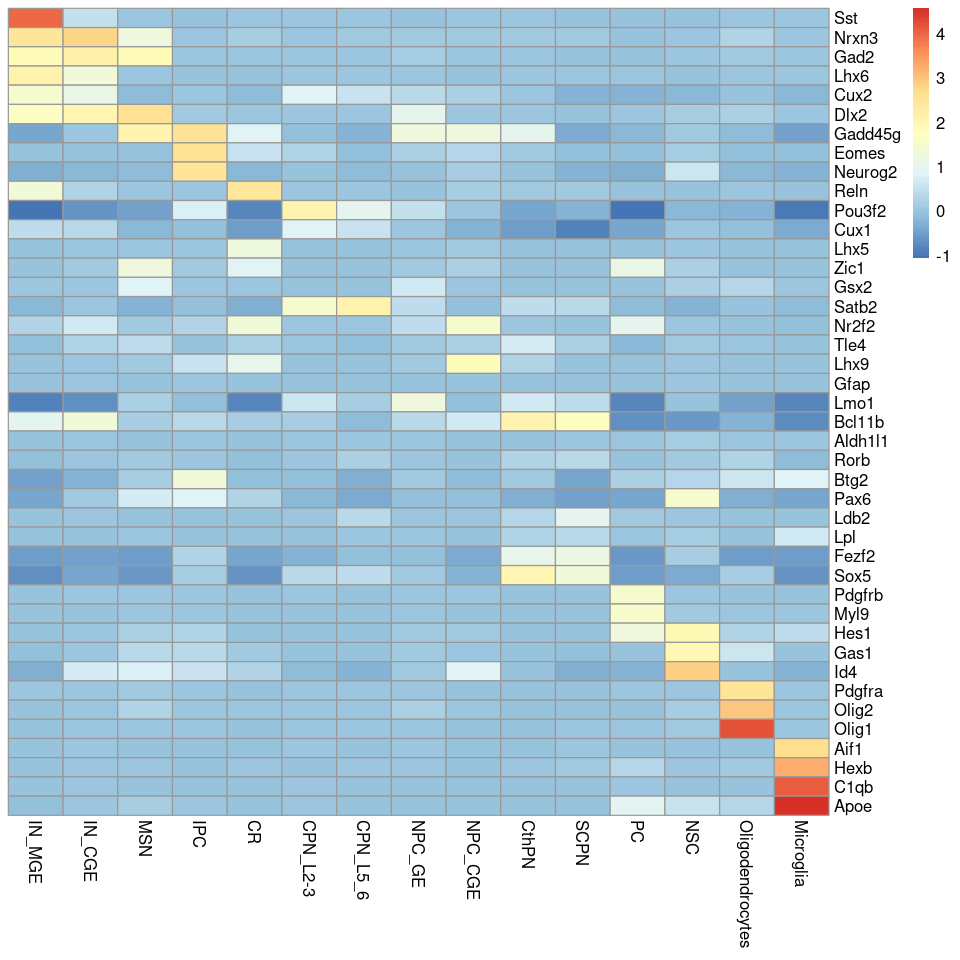

In [388]:
pheatmap::pheatmap(log2(st_marks_mat), cluster_cols = F, cluster_rows = F)

In [433]:
non_cort_st

[1] "IN_MGE"    "PC"        "CR"        "MSN"       "NPC_GE"    "NPC_CGE"  
[7] "IN_CGE"    "Microglia"

In [434]:
top_3_st[,351]

[1] "Oligodendrocytes" "IN_CGE"           "NSC"

In [436]:
sort(mcs_non_cort)

[1]   7  11  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94
 [19]  95  96  97 121 122 123 128 129 130 131 132 158 161 163 173 232 233 234
 [37] 237 266 285 296 297 298 299 300 302 305 306 307 308 309 312 313 320 321
 [55] 322 326 327 328 329 330 331 332 339 340 341 342 343 344 345 346 347 348
 [73] 349 350 351 352 353 354 357 358 361 363 364 365 366 367 368 369 370 371
 [91] 373 374 375 378 379 380 382 383 397 403 418 419 436 441 442 444

In [438]:
t(top_3_st[,mcs_non_cort])

79,IN_CGE,IN_MGE,MSN
80,IN_CGE,IN_MGE,MSN
81,IN_CGE,MSN,IN_MGE
82,IN_CGE,IN_MGE,MSN
83,IN_CGE,MSN,IN_MGE
84,IN_MGE,IN_CGE,MSN
85,IN_CGE,IN_MGE,MSN
86,IN_CGE,IN_MGE,MSN
87,IN_CGE,IN_MGE,MSN
88,IN_CGE,IN_MGE,MSN
89,IN_CGE,IN_MGE,MSN


In [363]:
mcs_non_cort = which(top_3_st[1,] %in% non_cort_st)
mcs_non_cort = mcs_non_cort[!(mcs_non_cort %in% mcs_not_npc)]

In [428]:
mcs_not_npc

[1] 215 160  28  38 214  60 124

In [430]:
sort(mcs_non_cort)

[1]   7  11  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94
 [19]  95  96  97 121 122 123 128 129 130 131 132 158 161 163 173 232 233 234
 [37] 237 266 285 296 297 298 299 300 302 305 306 307 308 309 312 313 320 321
 [55] 322 326 327 328 329 330 331 332 339 340 341 342 343 344 345 346 347 348
 [73] 349 350 351 352 353 354 357 358 361 363 364 365 366 367 368 369 370 371
 [91] 373 374 375 378 379 380 382 383 397 403 418 419 436 441 442 444

In [431]:
sort(mc@mc_fp[marks_all,351])

Fezf2       Lmo1       Pax6     Bcl11b     Pou3f2    Neurog2    Gadd45g 
 0.6878360  0.7320411  0.8037815  0.8283704  0.8374958  0.8833500  0.8990258 
      Cux1      Eomes        Id4       Cux2       Lhx9        Lpl      Nr2f2 
 0.9332338  0.9570404  0.9680082  0.9702014  0.9794177  0.9794478  0.9865680 
      Zic1       Ldb2       Aif1       C1qb       Gfap       Lhx5     Pdgfrb 
 0.9992361  0.9994838  1.0000000  1.0000000  1.0000000  1.0000000  1.0000000 
     Satb2       Lhx6        Sst       Reln       Tle4       Myl9    Aldh1l1 
 1.0016400  1.0074716  1.0090444  1.0092738  1.0108539  1.0110482  1.0302313 
      Hexb       Gad2       Sox5       Dlx2       Rorb      Nrxn3       Hes1 
 1.0675964  1.0752251  1.0849159  1.1440860  1.1774011  1.2084944  1.2093379 
      Gsx2       Apoe       Btg2       Gas1     Pdgfra      Olig2      Olig1 
 1.2249667  1.2502073  1.4936644  1.5040018  5.8039254  7.8677615 18.4510971

In [364]:
mcell_mc2d_plot(nm, colors = ifelse(1:nrow(mark_scores) %in% mcs_non_cort, 'red', 'black'), fn_suf = '_test_non_cort')

png 
  2

In [361]:
mcell_mc2d_plot(nm, colors = ifelse(1:nrow(mark_scores) %in% mcs_not_npc, 'red', 'black'), fn_suf = '_test_non_npc')

png 
  2

In [347]:
tgs_cor(t(mc@mc_fp[c('Pou3f2', 'Rnd2', 'Sstr2', 'Nrp1', 'Dlx1', 'Gsx2', 'Lhx9'),npc_mc]), spearman = T)

,Pou3f2,Rnd2,Sstr2,Nrp1,Dlx1,Gsx2,Lhx9
Pou3f2,1.00000000,0.48814229,0.5760870,0.38438735,0.15415020,-0.05298869,-0.1966889
Rnd2,0.48814229,1.00000000,0.5790514,0.02272727,-0.08399209,0.06257712,0.3899185
Sstr2,0.57608696,0.57905138,1.0000000,0.66403162,-0.13932806,-0.37193014,-0.2105263
Nrp1,0.38438735,0.02272727,0.6640316,1.00000000,-0.17391304,-0.66816214,-0.6053867
Dlx1,0.15415020,-0.08399209,-0.1393281,-0.17391304,1.00000000,0.49405645,0.1665431
Gsx2,-0.05298869,0.06257712,-0.3719301,-0.66816214,0.49405645,1.00000000,0.5234557
Lhx9,-0.19668891,0.38991847,-0.2105263,-0.60538672,0.16654312,0.52345572,1.0000000


In [116]:
table(cmd[names(mc@mc)[mc@mc %in% which(legc['Dlx1',] >= -16)],'t'])


 12  13  14  15  16  17  18 
  8  62  47 245 161 234  90 

In [107]:
which(mc@mc_fp['Dlx1',] >= 1.5)

79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97 296 
 79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97 296 
326 327 328 329 330 331 332 339 340 341 342 343 344 345 346 347 348 349 371 
326 327 328 329 330 331 332 339 340 341 342 343 344 345 346 347 348 349 371

In [117]:
top_3_st[1,mc@mc_fp['Dlx1',] >= 1.5]

79       80       81       82       83       84       85       86 
"IN_CGE" "IN_CGE" "IN_CGE" "IN_CGE" "IN_CGE" "IN_MGE" "IN_CGE" "IN_CGE" 
      87       88       89       90       91       92       93       94 
"IN_CGE" "IN_CGE" "IN_CGE" "IN_CGE" "IN_CGE" "IN_CGE" "IN_CGE" "IN_CGE" 
      95       96       97      296      326      327      328      329 
"IN_CGE" "IN_CGE" "IN_CGE" "NPC_GE"    "MSN"    "IPC"    "MSN"    "MSN" 
     330      331      332      339      340      341      342      343 
   "MSN"    "MSN" "NPC_GE" "IN_CGE"    "MSN" "IN_CGE" "IN_CGE" "IN_CGE" 
     344      345      346      347      348      349      371 
"IN_CGE"    "MSN"    "MSN" "IN_CGE"    "MSN" "IN_CGE"    "MSN"

In [9]:
# legc = log2(mc@e_gc + 1e-07)

# legcz = t(apply(legc, 1, function(x) (x - mean(x))/sd(x)))

# marks_all = sort(unique(unlist(mg_bon$marks)))

# legcz_marks = legcz[marks_all,]

In [70]:
marks_all

[1] "Aif1"    "Aldh1l1" "Apoe"    "Bcl11b"  "Btg2"    "C1qb"    "Cux1"   
 [8] "Cux2"    "Dlx2"    "Eomes"   "Fezf2"   "Gad2"    "Gadd45g" "Gas1"   
[15] "Gfap"    "Gsx2"    "Hes1"    "Hexb"    "Id4"     "Ldb2"    "Lhx5"   
[22] "Lhx6"    "Lhx9"    "Lmo1"    "Lpl"     "Myl9"    "Neurog2" "Nr2f2"  
[29] "Nrxn3"   "Olig1"   "Olig2"   "Pax6"    "Pdgfra"  "Pdgfrb"  "Pou3f2" 
[36] "Reln"    "Rorb"    "Satb2"   "Sox2"    "Sox5"    "Sst"     "Tle4"   
[43] "Vim"     "Zic1"

In [71]:
marks_all = sort(unique(unlist(mg_bon$marks)))
marks_all = marks_all[!(marks_all %in% c('Apoe','Sox2', 'Vim'))]
legcz_marks = mc@mc_fp[marks_all,]

In [115]:
nm = 'pl'

In [117]:
sapply(marks_all, function(g) mcell_mc2d_plot_gene(nm,g))

Aif1.png Aldh1l1.png    Apoe.png  Bcl11b.png    Btg2.png    C1qb.png 
          2           2           2           2           2           2 
   Cux1.png    Cux2.png    Dlx2.png   Eomes.png   Fezf2.png    Gad2.png 
          2           2           2           2           2           2 
Gadd45g.png    Gas1.png    Gfap.png    Gsx2.png    Hes1.png    Hexb.png 
          2           2           2           2           2           2 
    Id4.png    Ldb2.png    Lhx5.png    Lhx6.png    Lhx9.png    Lmo1.png 
          2           2           2           2           2           2 
    Lpl.png    Myl9.png Neurog2.png   Nr2f2.png   Nrxn3.png   Olig1.png 
          2           2           2           2           2           2 
  Olig2.png    Pax6.png  Pdgfra.png  Pdgfrb.png  Pou3f2.png    Reln.png 
          2           2           2           2           2           2 
   Rorb.png   Satb2.png    Sox5.png     Sst.png    Tle4.png    Zic1.png 
          2           2           2           2           2           2

In [121]:
marks_gset = scdb_gset(paste0(nm, '_marks'))

In [122]:
sapply(names(marks_gset@gene_set), function(g) mcell_mc2d_plot_gene(nm,g))

AY036118.png    Pou3f2.png      Nfix.png    Pou3f1.png      Sox4.png 
            2             2             2             2             2 
  Cttnbp2.png      Nrp1.png    Sema3c.png     Unc5d.png     Meis2.png 
            2             2             2             2             2 
  Igfbpl1.png      Pcp4.png      Tcf4.png     Sox11.png      Nfib.png 
            2             2             2             2             2 
    Auts2.png      Rnd2.png    Sema6d.png   Neurod6.png      Mafb.png 
            2             2             2             2             2 
      Arx.png       Maf.png       Sp9.png       Sst.png       Npy.png 
            2             2             2             2             2 
     Dlx2.png      Gad2.png     Nrxn3.png   Dlx6os1.png      Dlx1.png 
            2             2             2             2             2 
    Ncam1.png    Malat1.png    Adarb2.png      Meg3.png    Tubb2a.png 
            2             2             2             2             2 
      Ina.png      Ly6h.png      Rtn1.png      Tbr1.png      Rprm.png 
            2             2             2             2             2 
    Islr2.png     Foxp2.png    Arpp21.png    Grin2b.png      Sox5.png 
            2             2             2             2             2 
    Opcml.png    Bcl11b.png     Foxp1.png      Mapt.png     Gap43.png 
            2             2             2             2             2 
    Mef2c.png       Nts.png     Ptprd.png      Tsix.png   Gm26699.png 
            2             2             2             2             2 
     Ier5.png      Clmp.png     Cntn2.png     Tiam2.png     Epha5.png 
            2             2             2             2             2 
     Xist.png     Robo2.png     Ttc28.png    Frmd4a.png     Igsf3.png 
            2             2             2             2             2 
    Gria2.png    Frmd4b.png   Gm17750.png   Gm42418.png    Pantr1.png 
            2             2             2             2             2 
  Runx1t1.png       Id2.png      Dab1.png      Syt4.png    Ptprz1.png 
            2             2             2             2             2 
    Gpm6a.png     Satb2.png   Bhlhe22.png     Flrt3.png      Hes5.png 
            2             2             2             2             2 
      Dbi.png     Fabp7.png       Mt3.png     Aldoc.png      Apoe.png 
            2             2             2             2             2 
      Ptn.png     Ddah1.png     Pclaf.png     Hmgb2.png     Top2a.png 
            2             2             2             2             2 
    Cenpf.png      Pax6.png Hist1h2ap.png  Hist1h1b.png      Cks2.png 
            2             2             2             2             2 
      Id4.png     Ccnd2.png Hist1h2ae.png     Ube2c.png     Olig2.png 
            2             2             2             2             2 
    Hmgn2.png      Mest.png       Ckb.png       Vim.png      Rbp1.png 
            2             2             2             2             2 
    Sparc.png     Cenpa.png Hist1h2ac.png      Dlx5.png    Igfbp7.png 
            2             2             2             2             2 
    Olig1.png      C1qb.png     Zfhx3.png      Six3.png      Isl1.png 
            2             2             2             2             2 
   Col4a1.png    Tyrobp.png      C1qa.png     Nr2f2.png      Lhx9.png 
            2             2             2             2             2 
  Gm28050.png      Pbx3.png     Stmn1.png    Crabp2.png       Ubb.png 
            2             2             2             2             2 
    Stmn2.png     Stmn4.png      Reln.png       Ndn.png      Nnat.png 
            2             2             2             2             2 
    Tubb3.png     Hbb-y.png   Cntnap2.png      Ebf1.png    Tuba1a.png 
            2             2             2             2             2 
  Gm26917.png     Mfap4.png    Elavl4.png    Zbtb20.png       Mdk.png 
            2             2             2             2             2 
    Sstr2.png   Neurod1.p

In [91]:
legcz_marks

,1,2,3,4,5,6,7,8,9,10,⋯,438,439,440,441,442,443,444,445,446,447
Aif1,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,⋯,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.0034398,1.0000000
Aldh1l1,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.0139949,1.0186639,1.0091684,1.0000000,1.0000000,⋯,1.0024974,1.0000000,1.0188657,1.0533938,1.0000000,1.0110449,1.0500476,1.0000000,1.0000000,1.0000000
Apoe,0.9520015,0.9784676,0.9822050,0.9477996,1.0366195,0.9879272,0.9925073,0.9920520,0.9919552,0.9895711,⋯,1.0346472,1.0657193,1.0884929,1.2447051,1.0896919,1.1363720,1.2997213,0.9827341,0.9886555,0.9965831
Bcl11b,1.5840014,1.7287862,1.2567562,1.3924390,0.9824724,1.2906290,1.1066917,1.4615540,0.9965012,0.9629447,⋯,0.6755184,0.6560004,0.6733915,0.7084508,0.7417180,0.6564164,0.6623166,0.6678226,0.7529937,0.6692528
Btg2,0.8875316,0.8996175,0.8746301,0.9232018,0.8944893,0.9683177,0.9363745,0.8333707,0.8234706,0.8704668,⋯,3.8662774,2.2589602,3.6683348,3.6255662,3.1866045,4.4811743,3.3022681,3.9797076,4.9459782,3.9909943
C1qb,1.0000000,1.0000000,1.0059600,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,1.0000000,⋯,1.0000000,1.0000000,1.0046779,1.0000000,1.0000000,1.0036645,1.0000000,1.0044985,1.0000000,1.0000000
Cux1,1.3066486,1.7432960,0.9832275,1.0874215,1.6696988,1.7706096,1.8887155,2.1574784,1.8750357,1.8315914,⋯,0.9047738,1.1704099,0.9797286,1.2344209,1.3859742,0.9500110,1.0236340,0.8506153,1.1706308,0.9854099
Cux2,1.2971682,1.6449369,1.1631197,1.2057716,1.8895838,2.2713509,2.1270800,2.0819846,1.5907593,1.6818583,⋯,0.9163133,0.9427938,0.9141349,0.9097980,1.0619623,0.8968708,0.9069339,0.8567569,0.8717648,0.9002260
Dlx2,0.9882015,0.9838398,0.9897035,0.9838398,1.0329579,0.9838398,0.9983697,0.9838398,1.0065560,1.0250739,⋯,0.9838398,0.9913944,1.0165895,1.0022790,0.9993250,0.9838398,0.9945065,0.9882656,0.9872240,0.9984027
Eomes,0.9898343,0.9493873,0.9772182,0.9556255,0.9806603,1.0816540,1.1766101,0.9459939,0.9481740,0.9848851,⋯,10.0035639,6.3176940,10.5325382,12.4049413,11.2345700,11.2579023,12.4066133,5.9595542,9.5225687,8.3565643


In [256]:
mark_scores = sapply(mg_bon$marks, function(x) {
    gns = as.character(stringr::str_split(x, ', '));
    gns = gns[!(gns %in% c('Apoe','Sox2', 'Vim'))]
    print(gns)
    return(apply(legcz_marks[gns,], 2, mean))
})
# purrr::map2_dfr(legcz_marks, 1, function(x) )

[1] "Pax6" "Hes1" "Id4"  "Gas1"
[1] "Neurog2" "Eomes"   "Btg2"    "Gadd45g"
[1] "Sox5"   "Tle4"   "Bcl11b"
[1] "Fezf2"  "Ldb2"   "Bcl11b"
[1] "Rorb"  "Satb2" "Cux1"  "Lpl"  
[1] "Cux1"   "Cux2"   "Satb2"  "Pou3f2"
[1] "Satb2" "Ldb2" 
[1] "Reln" "Lhx5"
[1] "Gad2" "Sst"  "Lhx6"
[1] "Gad2"  "Nrxn3"
[1] "Gsx2" "Lmo1"
[1] "Lhx9"  "Nr2f2"
[1] "Gad2" "Dlx2" "Zic1"
[1] "Aif1" "C1qb" "Hexb"
[1] "Pdgfrb" "Myl9"  
[1] "Olig1"  "Olig2"  "Pdgfra"
[1] "Gfap"    "Aldh1l1"


In [257]:
colnames(mark_scores) = mg_bon$st

In [258]:
head(mark_scores)

,NSC,IPC,CthPN,SCPN,Stellate_L4,CPN_L2-3,CPN_L5_6,CR,IN_MGE,IN_CGE,NPC_GE,NPC_CGE,MSN,Microglia,PC,Oligodendrocytes,Astrocytes
1,0.8983531,1.0296782,1.567612,1.2798897,1.617838,1.984960,2.120661,0.9928798,0.9960824,0.9881760,1.375760,0.9964655,0.9871455,0.9968062,1.0009286,0.9988919,1.000000
2,0.9232061,1.0312547,1.613876,1.2308774,1.719779,2.451988,2.092762,1.0075261,0.9957293,0.9781959,1.271422,0.9624450,0.9867402,1.0022757,1.0050724,0.9988919,1.000000
3,0.9048474,0.9011273,1.126167,1.1142630,1.280968,1.523026,1.612722,1.0020283,1.0050344,0.9945687,1.604017,1.3425321,0.9950426,1.0067345,1.0016919,1.0028586,1.000000
4,0.8939273,0.9303062,1.292669,1.1904283,1.538663,1.980545,2.035231,0.9980974,1.0032934,0.9876591,1.464386,0.9902040,1.0025280,1.0000000,0.9987119,0.9988919,1.000000
5,0.9251769,0.9079043,1.025078,0.9536692,1.508377,2.581913,1.672469,0.9941071,1.0328273,1.0542962,1.402377,1.1055461,1.0166517,0.9968062,1.0044009,1.0103154,1.000000
6,0.9542786,0.9574575,1.165762,1.0200640,1.545785,2.680176,1.678963,0.9885342,1.0057454,1.0057021,1.354371,1.0240873,0.9904793,0.9968062,0.9987119,1.0082063,1.006997


In [259]:
quantile(apply(mark_scores, 1, function(x) max(x)/x[order(x, decreasing = T)[[2]]]), seq(0,1,0.05))

0%        5%       10%       15%       20%       25%       30%       35% 
 1.000131  1.029561  1.069419  1.104512  1.140879  1.179634  1.226964  1.256427 
      40%       45%       50%       55%       60%       65%       70%       75% 
 1.317857  1.377414  1.451810  1.562386  1.684305  1.855107  2.083589  2.625592 
      80%       85%       90%       95%      100% 
 3.413027  4.102435  4.540181  5.420705 10.226411

In [260]:
top_3 = apply(mark_scores, 1, function(x) {ord = order(x, decreasing = T);
                                  return(head(setNames(x[ord], colnames(mark_scores)[ord]), 3))})
t(top_3)

1,2.120661,1.984960,1.617838
2,2.451988,2.092762,1.719779
3,1.612722,1.604017,1.523026
4,2.035231,1.980545,1.538663
5,2.581913,1.672469,1.508377
6,2.680176,1.678963,1.545785
7,2.882108,1.598676,1.518590
8,3.137261,2.159380,1.840390
9,2.969092,1.960660,1.696343
10,2.903235,2.146126,1.774945
11,2.912427,2.118472,1.785367


In [261]:
top_3_st = apply(mark_scores, 1, function(x) {ord = order(x, decreasing = T);
                                  return(head(colnames(mark_scores)[ord], 3))})
t(top_3_st)

1,CPN_L5_6,CPN_L2-3,Stellate_L4
2,CPN_L2-3,CPN_L5_6,Stellate_L4
3,CPN_L5_6,NPC_GE,CPN_L2-3
4,CPN_L5_6,CPN_L2-3,Stellate_L4
5,CPN_L2-3,CPN_L5_6,Stellate_L4
6,CPN_L2-3,CPN_L5_6,Stellate_L4
7,CPN_L2-3,CPN_L5_6,Stellate_L4
8,CPN_L2-3,CPN_L5_6,Stellate_L4
9,CPN_L2-3,CPN_L5_6,Stellate_L4
10,CPN_L2-3,CPN_L5_6,Stellate_L4
11,CPN_L2-3,CPN_L5_6,Stellate_L4


In [262]:
sort(table(top_3_st[1,]))


          IN_MGE        Microglia Oligodendrocytes               PC 
               1                1                1                1 
              CR             SCPN           NPC_GE              MSN 
               3                3                5               10 
         NPC_CGE           IN_CGE         CPN_L5_6            CthPN 
              18               28               37               69 
        CPN_L2-3              IPC              NSC 
              82               89               99 

In [263]:
non_cort_st = c('IN_MGE', 'PC', 'CR', 'MSN', 'NPC_GE', 'NPC_CGE', 'IN_CGE', 'Microglia')

In [264]:
top_3_non_cort = t(top_3[,top_3_st[1,] %in% non_cort_st])
top_3_non_cort_st = t(top_3_st[,top_3_st[1,] %in% non_cort_st])

In [272]:
sort(which(top_3_st[1,] %in% non_cort_st))

[1]  28  38  60  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94
[20]  95  96  97 121 124 128 160 214 215 326 328 329 330 331 332 339 340 341 342
[39] 343 344 345 346 347 348 349 352 353 354 357 358 361 363 364 365 366 367 368
[58] 369 370 371 373 374 375 378 380 382 383

In [300]:
nsc_mcs = which(top_3_st[1,] == 'NSC')
# nsc_mcs = nsc_mcs[nsc_mcs != 350]
nsc_mcs

221 225 229 230 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 
221 225 229 230 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 
248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 
248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 
268 269 270 271 272 273 274 275 276 277 278 279 280 281 282 283 284 285 286 287 
268 269 270 271 272 273 274 275 276 277 278 279 280 281 282 283 284 285 286 287 
288 289 290 291 292 293 294 295 296 297 298 299 300 301 302 303 304 305 306 307 
288 289 290 291 292 293 294 295 296 297 298 299 300 301 302 303 304 305 306 307 
308 309 310 311 312 313 314 315 316 317 318 319 320 321 322 323 324 325 350 
308 309 310 311 312 313 314 315 316 317 318 319 320 321 322 323 324 325 350

In [301]:
legc_nsc = log2(mc@e_gc[,top_3_st[1,] == 'NSC'] + 1E-07)

In [302]:
cor_nsc = tgs_cor(legc_nsc, spearman = T)

In [303]:
dist_nsc = as.matrix(tgs_dist(t(legc_nsc)))

In [304]:
ord_nsc_mc_by_day = order(apply(prc_day[nsc_mcs,], 1, function(x) sum(x*1:length(x))/sum(x)))

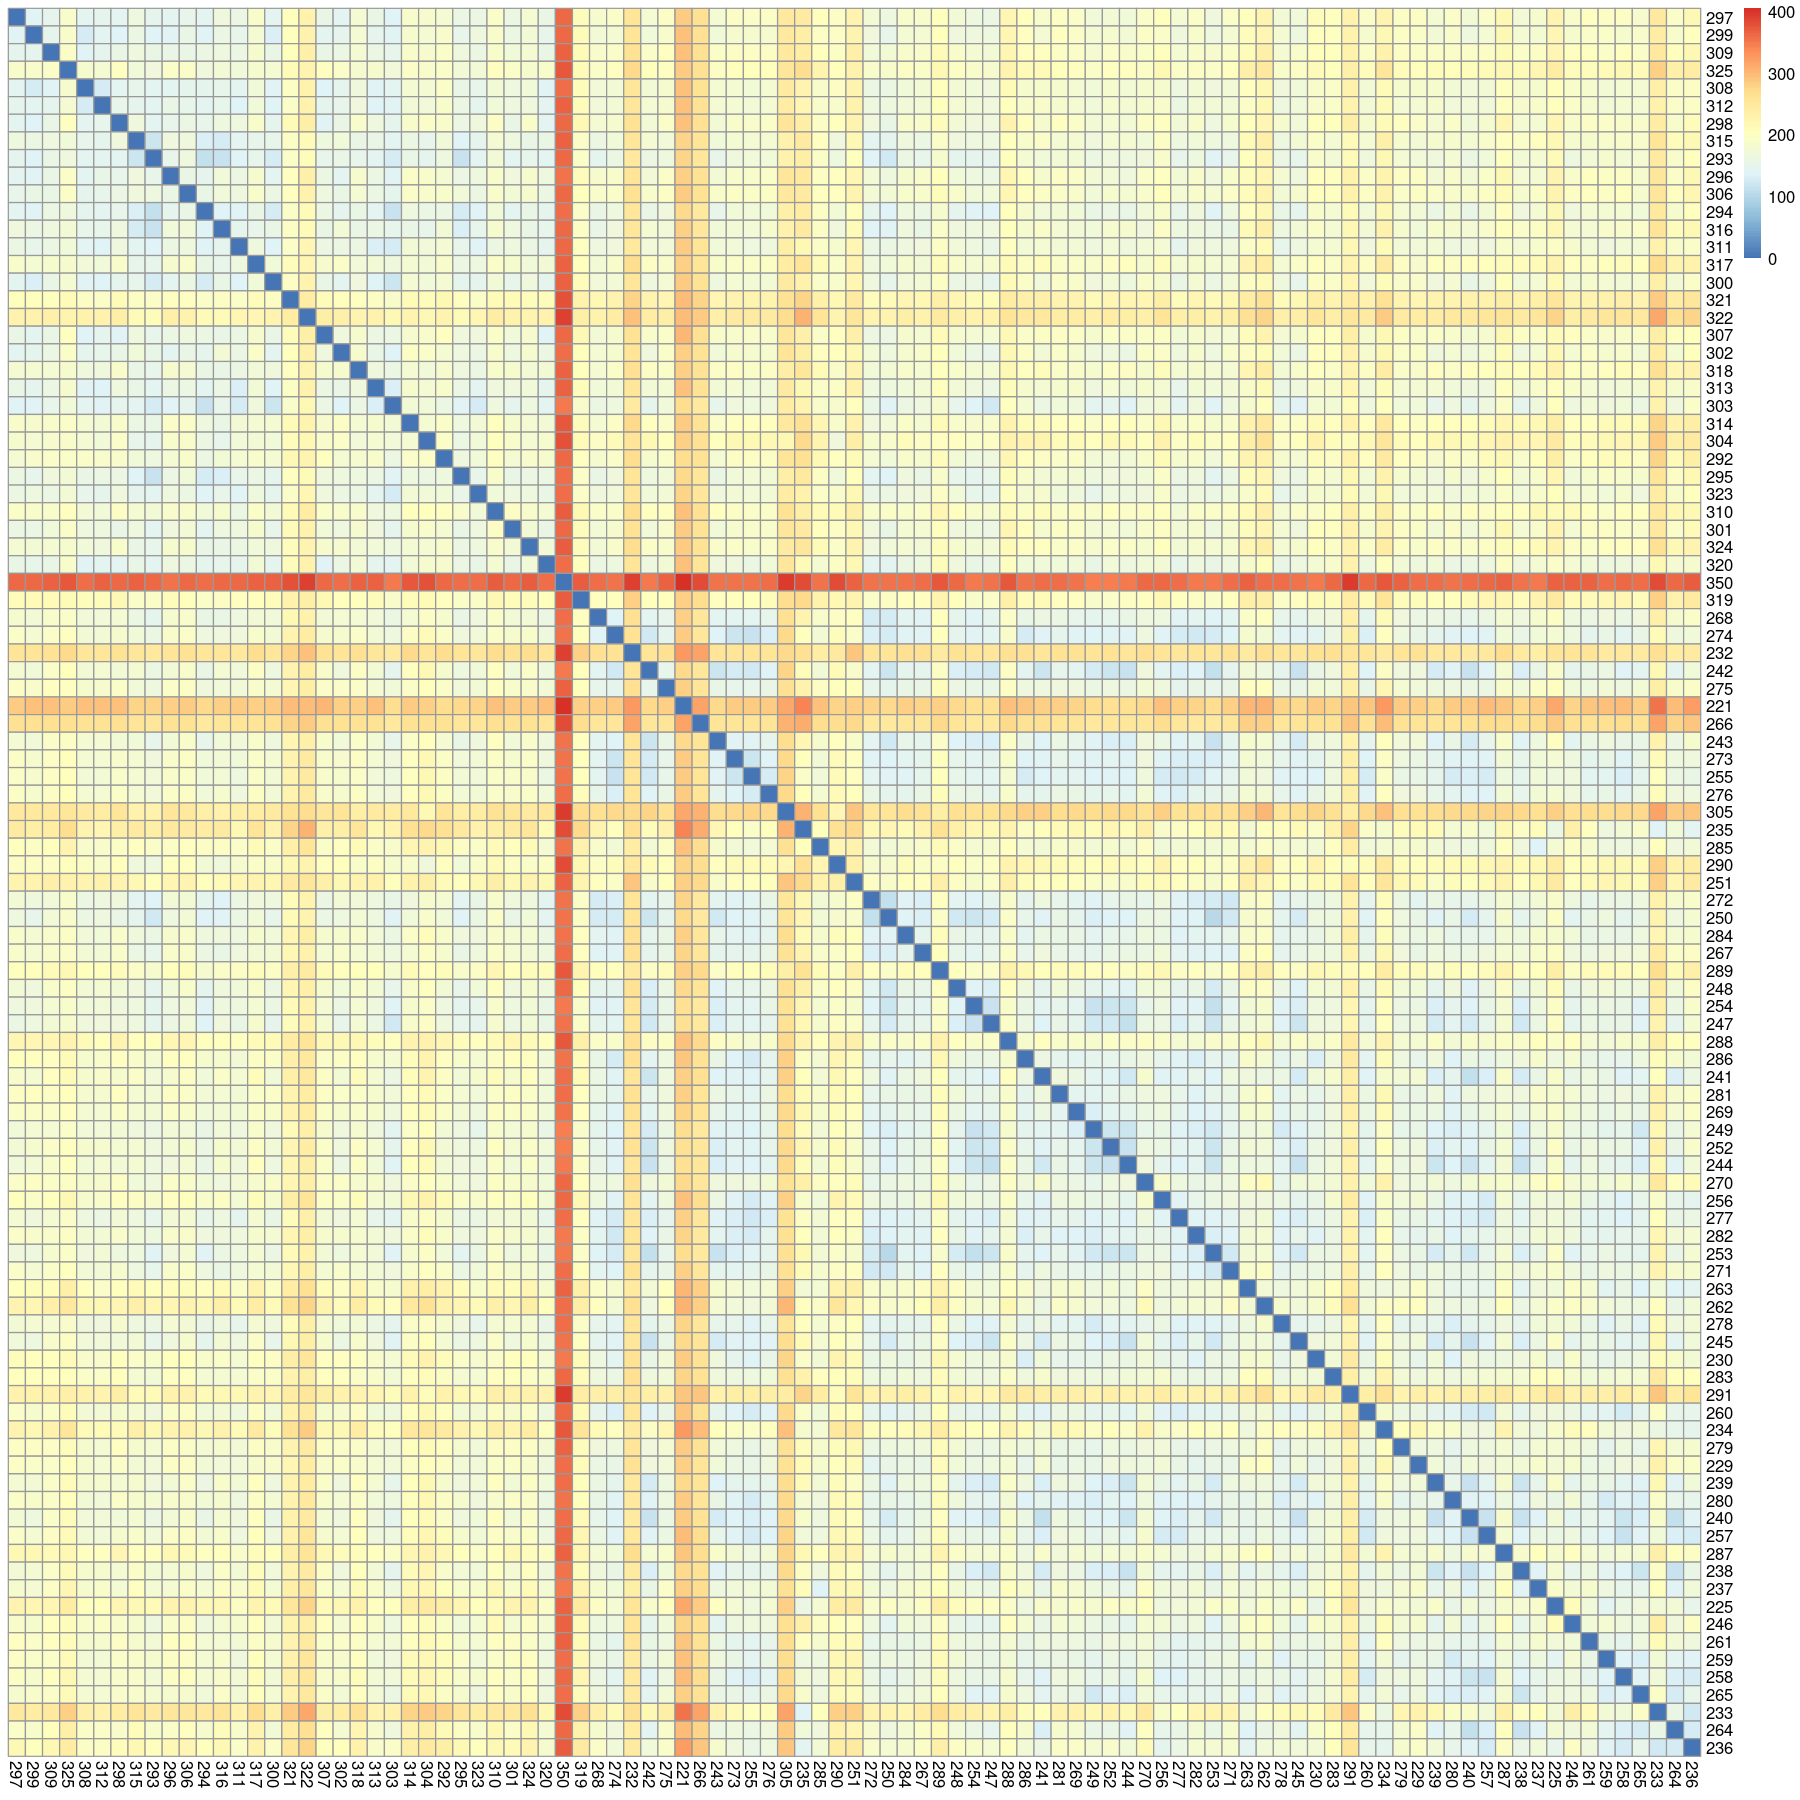

In [305]:
options(repr.plot.height = 15, repr.plot.width = 15)
pheatmap::pheatmap(dist_nsc[ord_nsc_mc_by_day,ord_nsc_mc_by_day], cluster_cols = F, cluster_rows = F)
options(repr.plot.height = 8, repr.plot.width = 8)

In [293]:
sort(mark_scores[92,])

NPC_GE              IPC               PC               CR 
       0.8092139        0.9115065        0.9987119        1.0005039 
         NPC_CGE         CPN_L2-3       Astrocytes Oligodendrocytes 
       1.0024961        1.0056176        1.0122506        1.0176701 
     Stellate_L4        Microglia         CPN_L5_6              NSC 
       1.0754792        1.0763778        1.3264440        1.5967372 
          IN_MGE              MSN             SCPN            CthPN 
       1.7947944        1.9055726        3.3830039        3.5032517 
          IN_CGE 
       3.5429042

In [289]:
sort(mark_scores[350,])

NPC_GE         CPN_L5_6        Microglia               PC 
       0.9072377        0.9420518        0.9968062        0.9987119 
      Astrocytes         CPN_L2-3 Oligodendrocytes      Stellate_L4 
       1.0000000        1.1097680        1.1119975        1.1601827 
            SCPN               CR           IN_MGE              MSN 
       1.2453502        1.2603630        1.2655157        1.4570579 
             IPC          NPC_CGE            CthPN           IN_CGE 
       1.5746032        2.0229915        2.1997481        2.5624594 
             NSC 
       3.2579736

In [292]:
sort(legcz_marks[,350], decreasing = T)

Pax6       Id4     Nrxn3      Tle4     Nr2f2    Bcl11b     Eomes      Hes1 
4.7848497 4.7329773 3.5089643 2.9830669 2.4230644 2.0783995 2.0605387 2.0131411 
  Gadd45g      Lhx9      Gad2      Sox5   Neurog2      Gas1      Reln      Dlx2 
1.8376160 1.6229187 1.6159544 1.5377778 1.5361839 1.5009263 1.4645949 1.3811970 
     Zic1      Cux2      Rorb      Cux1      Gsx2    Pdgfra     Olig2      Lhx6 
1.3740224 1.3443139 1.3245967 1.2813558 1.1699409 1.1699409 1.1660515 1.1340147 
      Lpl      Lhx5      Apoe       Sst      Aif1   Aldh1l1      C1qb      Gfap 
1.1095495 1.0561311 1.0546891 1.0465782 1.0000000 1.0000000 1.0000000 1.0000000 
    Olig1    Pdgfrb      Myl9      Hexb      Ldb2     Satb2    Pou3f2      Btg2 
1.0000000 1.0000000 0.9974238 0.9904186 0.9588747 0.9252290 0.8881735 0.8640742 
    Fezf2      Lmo1 
0.6987765 0.6445346

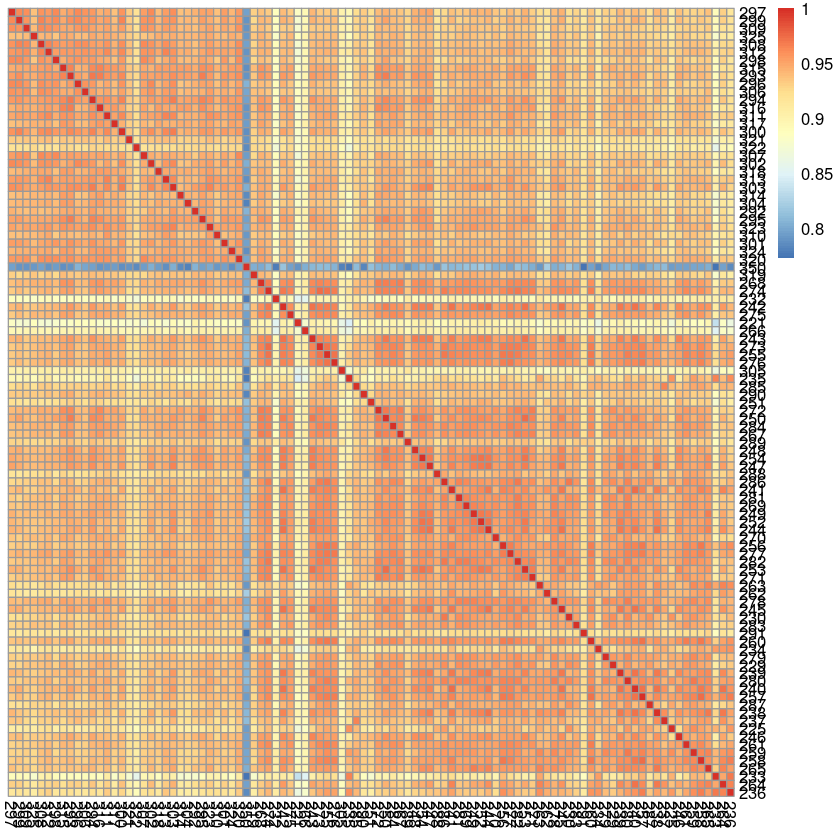

In [281]:
pheatmap::pheatmap(cor_nsc[ord_nsc_mc_by_day,ord_nsc_mc_by_day], cluster_cols = F, cluster_rows = F)

In [274]:
mcell_mc2d_plot(nm, colors = ifelse(1:length(unique(mc@mc)) %in% sort(which(top_3_st[1,] %in% non_cort_st)), 'red', 'black'), fn_suf = '_is_non_cort')

png 
  2

In [265]:
dim(top_3_non_cort)

[1] 67  3

In [266]:
length(mc@mc[mc@mc %in% which(top_3_st[1,] %in% non_cort_st)])

[1] 9031

In [268]:
length(mc@mc)

[1] 58037

In [267]:
mci = 28

sort(legcz_marks[,mci], decreasing = T)

sort(mark_scores[mci,], decreasing = T)

table(cmd[names(mc@mc)[mc@mc %in% mci],'t'])

Nr2f2      Lmo1     Satb2    Bcl11b      Cux2      Sox5   Gadd45g    Pou3f2 
2.4034711 2.1276444 1.7239228 1.6771266 1.6545422 1.5883611 1.5347047 1.5046018 
     Cux1      Tle4     Fezf2   Neurog2     Eomes    Pdgfrb       Sst      Lhx9 
1.2909271 1.1206108 1.1014712 1.0459326 1.0393253 1.0134817 1.0110695 1.0071724 
     Aif1   Aldh1l1      C1qb      Gfap      Gsx2      Lhx5     Olig1    Pdgfra 
1.0000000 1.0000000 1.0000000 1.0000000 1.0000000 1.0000000 1.0000000 1.0000000 
     Myl9      Reln     Olig2      Hes1      Btg2      Hexb      Lhx6      Dlx2 
0.9974238 0.9969013 0.9966756 0.9956312 0.9918032 0.9904186 0.9894102 0.9838398 
    Nrxn3      Gad2       Lpl      Apoe      Zic1      Gas1      Ldb2       Id4 
0.9815028 0.9814366 0.9811159 0.9801053 0.9787292 0.9764910 0.9718020 0.9707858 
     Rorb      Pax6 
0.9458204 0.7452701

NPC_CGE           NPC_GE         CPN_L2-3            CthPN 
       1.7053218        1.5638222        1.5434985        1.4620328 
        CPN_L5_6             SCPN      Stellate_L4              IPC 
       1.3478624        1.2501333        1.2354466        1.1529414 
              PC       Astrocytes Oligodendrocytes               CR 
       1.0054528        1.0000000        0.9988919        0.9984507 
       Microglia           IN_MGE           IN_CGE              MSN 
       0.9968062        0.9939721        0.9814697        0.9813352 
             NSC 
       0.9220445


14 15 16 17 18 
 2 46 28 15  2 

In [88]:
cbind(top_3_non_cort_st[top_3_non_cort[,1] - top_3_non_cort[,2] < 1,], top_3_non_cort[top_3_non_cort[,1] - top_3_non_cort[,2] < 1,])

28,NPC_CGE,NPC_GE,CPN_L2-3,1.7053217828336,1.56382221740572,1.54349849796399
38,NPC_GE,CPN_L2-3,CPN_L5_6,1.69849069883322,1.67388419349333,1.34540298824416
60,NPC_GE,CPN_L2-3,NPC_CGE,1.70559546792137,1.70407254373574,1.37917572253527
92,IN_CGE,CthPN,SCPN,3.54290418466219,3.5032516519467,3.38300392873895
124,NPC_GE,NPC_CGE,CPN_L5_6,1.40259957084573,1.22599625572674,1.11151778461604
128,IN_CGE,CPN_L5_6,CPN_L2-3,2.72552268600541,2.23354550018098,1.80606581462866
160,NPC_CGE,CPN_L2-3,CPN_L5_6,1.8398858030665,1.80337363426366,1.43110649998431
214,NPC_CGE,CPN_L2-3,CPN_L5_6,1.56440594268683,1.36955005982255,1.36638533109854
215,NPC_GE,CPN_L5_6,SCPN,1.7107708243781,1.34883515767101,1.34310603170859
326,MSN,IPC,IN_CGE,3.7439102825704,2.82237992084089,2.40115419361809
328,MSN,IN_CGE,IPC,2.84667370474915,2.49020978741418,1.56829899322261


In [94]:
length(names(mc@mc)[mc@mc %in% which(top_3_st[1,] %in% non_cort_st)])

[1] 10301

In [149]:
scdb_init('scdb', force_reinit = T)

initializing scdb to scdb



In [138]:
mat = scdb_mat('pl')

In [139]:
cmd = mat@cell_metadata

In [140]:
head(cmd)

,type,batch_set_id,amp_batch_id,seq_batch_id,spike_count,day,t
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>
AAACCCAAGACGACTG-1,10x,E12_rep1_L1,E12_rep1_L1,E12_rep1_L1,0,E12,12
AAACCCAAGACGGAAA-1,10x,E12_rep1_L1,E12_rep1_L1,E12_rep1_L1,0,E12,12
AAACCCACAACCGTGC-1,10x,E12_rep1_L1,E12_rep1_L1,E12_rep1_L1,0,E12,12
AAACCCAGTCGGTGAA-1,10x,E12_rep1_L1,E12_rep1_L1,E12_rep1_L1,0,E12,12
AAACCCAGTGTCATGT-1,10x,E12_rep1_L1,E12_rep1_L1,E12_rep1_L1,0,E12,12
AAACCCAGTTCTTGTT-1,10x,E12_rep1_L1,E12_rep1_L1,E12_rep1_L1,0,E12,12


In [135]:
table(as.character(cmd$day))


  E12   E13   E14   E15   E16   E17   E18 
15819 11484 10829  9582 11833 13199 15160 

In [151]:
mcell_mc2d_plot_by_factor(nm, nm, meta_field = 'day', single_plot = F, colors = rep('black', length(unique(mc@mc))))

In [80]:
which(mc@mc %in% which(top_3_st[1,] == 'Astrocytes'))

[1] 14356 34953 35807 39634 41028 41351 41492 41806 42148 42502 42509 42827
 [13] 42835 42916 43153 43194 43525 44067 44440 44591 44729 44989 45048 45427
 [25] 45674 45814 46322 46761 47032 47425 47561 47750 47990 48071 48142 48359
 [37] 48414 48665 48717 48897 49180 49328 49793 49917 49956 49982 50043 50114
 [49] 50141 50156 50197 50216 50227 50244 50289 50316 50323 50329 50332 50347
 [61] 50380 50419 50446 50481 50498 50506 50529 50569 50586 50707 50718 50729
 [73] 50779 50792 50797 50820 50822 50839 50840 50863 50868 50869 50875 50906
 [85] 50948 50956 51019 51056 51146 51183 51197 51205 51268 51324 51349 51444
 [97] 51449 51454 51472 51500 51533 51535 51592 51602 51643 51646 51687 51721
[109] 51751 51812 51858 51861 51864 51942 51955 51989 52025 52030 52031 52042
[121] 52048 52078 52085 52098 52132 52186 52204 52212 52224 52269 52290 52313
[133] 52318 52339 52361 52388 52416 52448 52528 52534 52545 52551 52558 52564
[145] 52615 52670 52701 52724 52744 52768 52786 52860 52877 52897 52899 52960
[157] 52973 52977 53004 53060 53069 53147 53200 53206 53236 53241 53263 53303
[169] 53335 53389 53495 53511 53559 53601 53631 53683 53687 53710 53732 53765
[181] 53775 53785 53796 53823 53880 53897 53909 53913 53975 54025 54054 54125
[193] 54136 54140 54153 54296 54307 54394 54437 54455 54506 54515 54677 54725
[205] 54732 54768 54829 54845 54852 54853 54868 54909 54925 54940 54983 55010
[217] 55041 55076 55176 55184 55198 55219 55244 55253 55258 55281 55285 55331
[229] 55347 55418 55467 55504 55622 55647 55690 55714 55728 55737 55742 55843
[241] 55866 55887 55889 55935 55943 56034 56041 56050 56064 56070 56142 56208
[253] 56217 56220 56262 56269 56302 56305 56321 56325 56346 56435 56515 56525
[265] 56601 56603 56604 56610 56638 56704 56723 56765 56777 56789 56841 56911
[277] 56917 56921 56958 56991 57005 57030 57042 57047 57079 57104 57129 57132
[289] 57160 57178 57225 57231 57238 57268 57281 57329 57359 57369 57379 57419
[301] 57444 57462 57506 57545 57563 57602 57610 57626 57648 57667 57672 57751
[313] 57791 57839 57858 57879 57905 57924 57937 57954 58003

In [93]:
table(cmd[names(mc@mc)[mc@mc %in% which(top_3_st[1,] == 'Astrocytes')],'t'])


 13  16  17  18 
  1   3  40 277 

In [45]:
mark_scores[order(apply(mark_scores, 1, function(x) max(x)/x[order(x, decreasing = T)[[2]]])),]

,NSC,IPC,CthPN,SCPN,Stellate_L4,CPN_L2-3,CPN_L5_6,CR,IN_MGE,IN_CGE,NPC_GE,NPC_CGE,MSN,Microglia,PC,Oligodendrocytes,Astrocytes
20,3.1484847,0.8607258,0.7898356,0.7648117,1.1382505,0.9045629,0.9342830,0.9948608,1.0104989,1.0801233,3.2905749,1.0072753,1.0015742,1.0864255,1.017631,3.290881,1.2183232
512,0.8088486,0.8556829,0.8308308,0.7857785,2.3759732,3.2522582,3.2538629,1.0144033,1.0057580,0.9978604,0.8238302,0.9576038,1.0005210,0.9961641,1.000000,1.016616,0.9980204
487,0.8086064,0.9650926,1.3245752,1.1225361,2.2558996,2.9749258,2.9836653,0.9973264,0.9942849,0.9817086,0.8739839,1.0138711,0.9889519,0.9951810,1.000000,1.000000,0.9869254
506,0.7996753,0.8970492,1.0219844,0.9049169,2.0512746,2.7307487,2.7396587,1.0330415,1.0207565,1.0800537,0.8675211,1.0705880,1.0215066,1.0119210,1.000000,1.000000,1.0065824
518,0.8046920,0.8304488,0.8600390,0.8051859,2.6399774,3.6390113,3.6173619,1.0036237,1.0077093,0.9954270,0.8184710,0.9640617,0.9932609,1.0011618,1.000000,1.000000,1.0047274
481,0.8148038,0.9083430,1.3889084,1.3878539,1.2451998,1.5062140,1.5159779,1.0091941,1.0223862,0.9999866,1.1037913,1.0067404,1.0859715,1.0216654,1.004633,1.000000,1.0133452
523,0.8141880,0.8261018,0.8504982,0.8825929,1.6601628,2.0966951,2.0815510,1.0158320,1.0241134,1.0073997,0.8839117,0.9698274,1.0186221,1.0033353,1.000000,1.031564,0.9989407
490,0.7865004,0.8484331,0.8457580,0.8536612,2.2622893,2.9924358,3.0169336,1.0236808,0.9982859,0.9817086,0.8511043,0.9897318,0.9884938,0.9843641,1.000000,1.013464,0.9822870
508,0.8936673,0.8015910,0.8226301,0.8623503,2.3927220,3.0920391,3.1179557,0.9982501,1.0089940,0.9899605,0.7828422,0.9576038,0.9951559,1.0142543,1.000000,1.000000,1.0149182
29,4.4114293,4.3684262,0.8223306,0.9450265,0.9885746,1.0918337,0.9563492,0.9899783,1.0086723,0.9943639,4.0232170,0.9854839,1.0050946,1.0827464,1.110375,1.006474,1.1413425


In [152]:
head(mark_scores)

,NSC,IPC,CthPN,SCPN,Stellate_L4,CPN_L2-3,CPN_L5_6,CR,IN_MGE,IN_CGE,NPC_GE,NPC_CGE,MSN,Microglia,PC,Oligodendrocytes,Astrocytes
1,0.8983531,1.0296782,1.567612,1.2798897,1.617838,1.984960,2.120661,0.9928798,0.9960824,0.9881760,1.375760,0.9964655,0.9871455,0.9856050,1.0009286,0.9988919,0.9840005
2,0.9232061,1.0312547,1.613876,1.2308774,1.719779,2.451988,2.092762,1.0075261,0.9957293,0.9781959,1.271422,0.9624450,0.9867402,0.9963237,1.0050724,0.9988919,0.9928225
3,0.9048474,0.9011273,1.126167,1.1142630,1.280968,1.523026,1.612722,1.0020283,1.0050344,0.9945687,1.604017,1.3425321,0.9950426,1.0006021,1.0016919,1.0028586,0.9940683
4,0.8939273,0.9303062,1.292669,1.1904283,1.538663,1.980545,2.035231,0.9980974,1.0032934,0.9876591,1.464386,0.9902040,1.0025280,0.9869499,0.9987119,0.9988919,0.9825999
5,0.9251769,0.9079043,1.025078,0.9536692,1.508377,2.581913,1.672469,0.9941071,1.0328273,1.0542962,1.402377,1.1055461,1.0166517,1.0067595,1.0044009,1.0103154,1.0122065
6,0.9542786,0.9574575,1.165762,1.0200640,1.545785,2.680176,1.678963,0.9885342,1.0057454,1.0057021,1.354371,1.0240873,0.9904793,0.9945864,0.9987119,1.0082063,1.0006407


In [153]:
dir.create('./figs/pl.st_scores')

In [156]:
seq_along(colnames(mark_scores))

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17

In [192]:
colspec = tgconfig::get_param("mcell_mc2d_gene_shades",'metacell')
max_lfp = 3
min_lfp = -max_lfp
sapply(seq_along(colnames(mark_scores)), function(x,cn,i) {
    x = pmin(pmax(log2(x[,i]), min_lfp), max_lfp) - min_lfp
    shades = colorRampPalette(colspec)(100 * (max_lfp-min_lfp) + 1)
    mc_cols = shades[round(100 * x) + 1]
    mcell_mc2d_plot(nm, colors = mc_cols, fig_fn = paste0('./figs/pl.st_scores/', cn[[i]], '.png'))
}, x = mark_scores, cn = colnames(mark_scores))

png png png png png png png png png png png png png png png png png 
  2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2

In [325]:
dir.create('./figs/pl.st_class')

In [327]:
colnames(mark_scores)

[1] "NSC"              "IPC"              "CthPN"            "SCPN"            
 [5] "Stellate_L4"      "CPN_L2-3"         "CPN_L5_6"         "CR"              
 [9] "IN_MGE"           "IN_CGE"           "NPC_GE"           "NPC_CGE"         
[13] "MSN"              "Microglia"        "PC"               "Oligodendrocytes"
[17] "Astrocytes"

In [326]:
sapply(seq_along(colnames(mark_scores)), function(x,cn,i) {
    mcell_mc2d_plot(nm, colors = ifelse(1:nrow(x) %in% which(top_3_st[1,] == cn[[i]]),'red','black'), fig_fn = paste0('./figs/pl.st_class/', cn[[i]], '.png'))
}, x = mark_scores, cn = colnames(mark_scores))

png png png png png png png png png png png png png png png png png 
  2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2

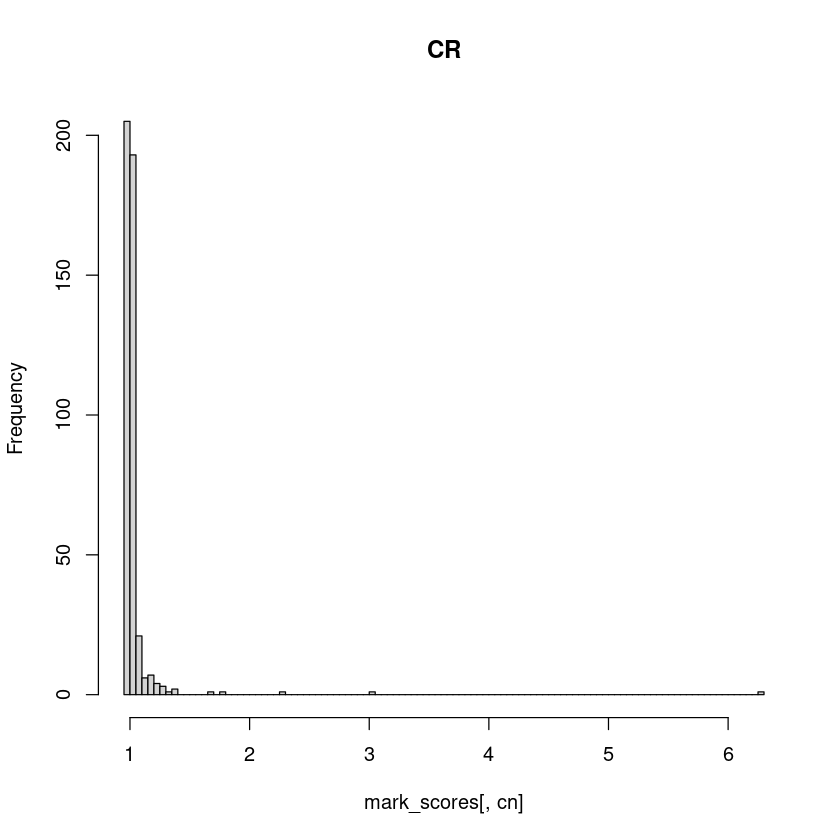

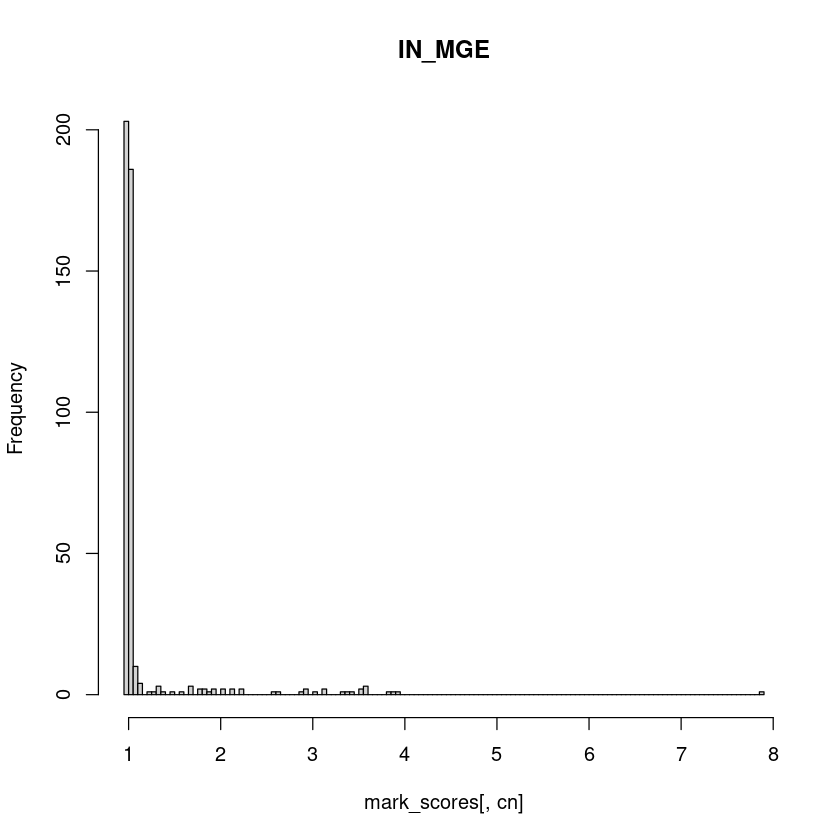

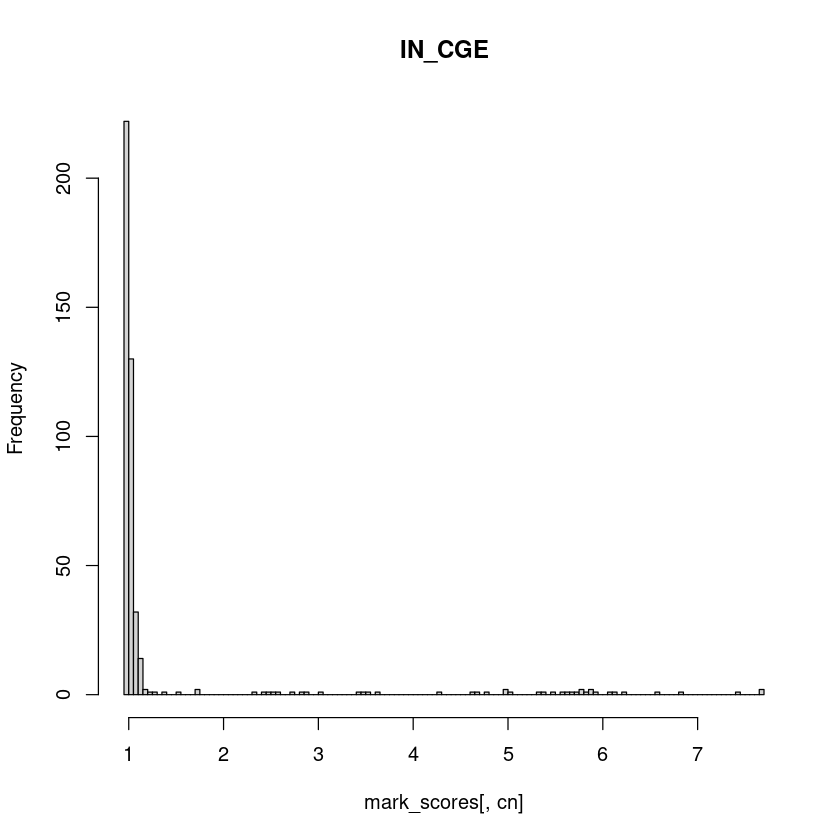

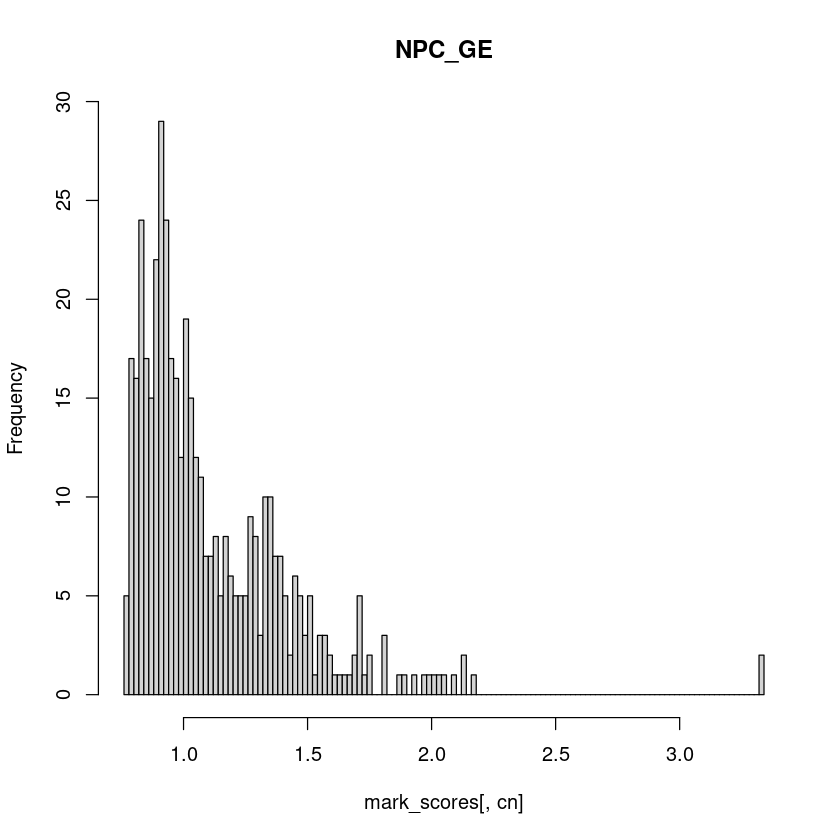

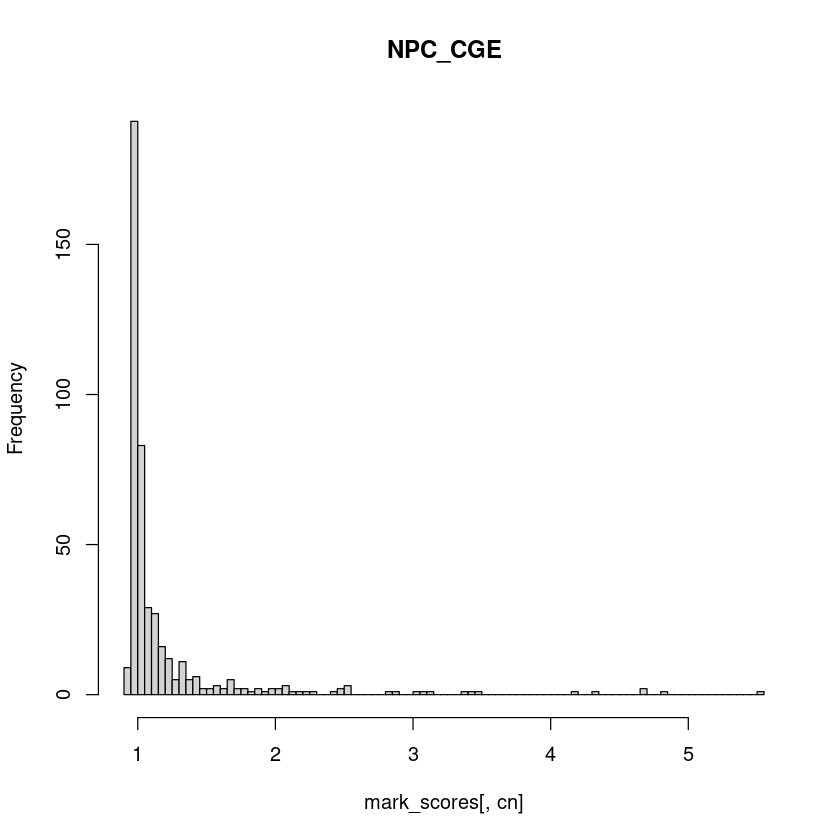

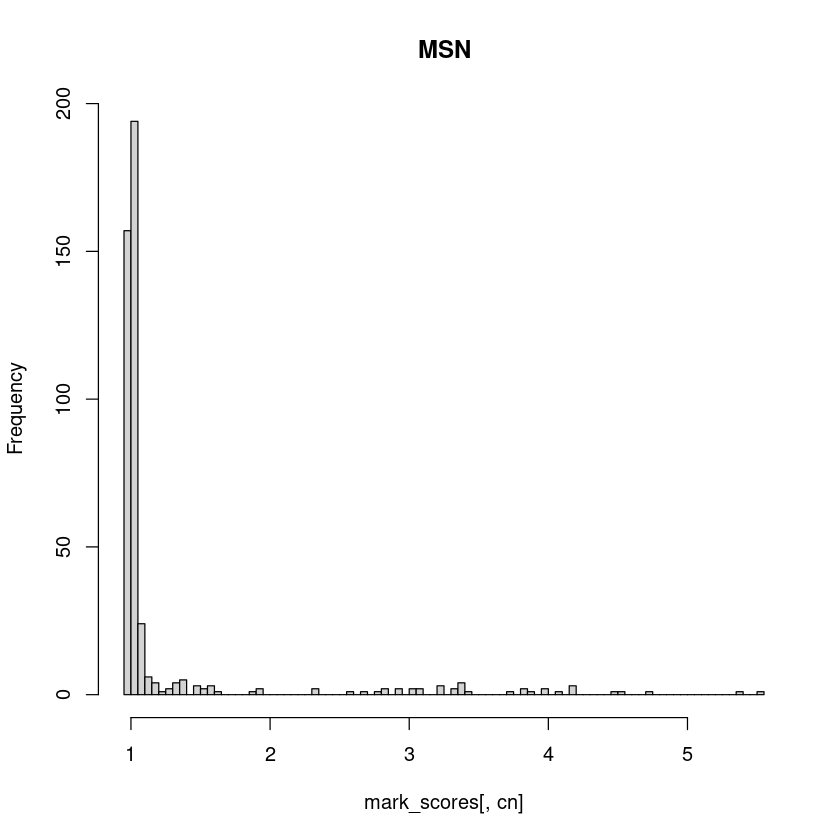

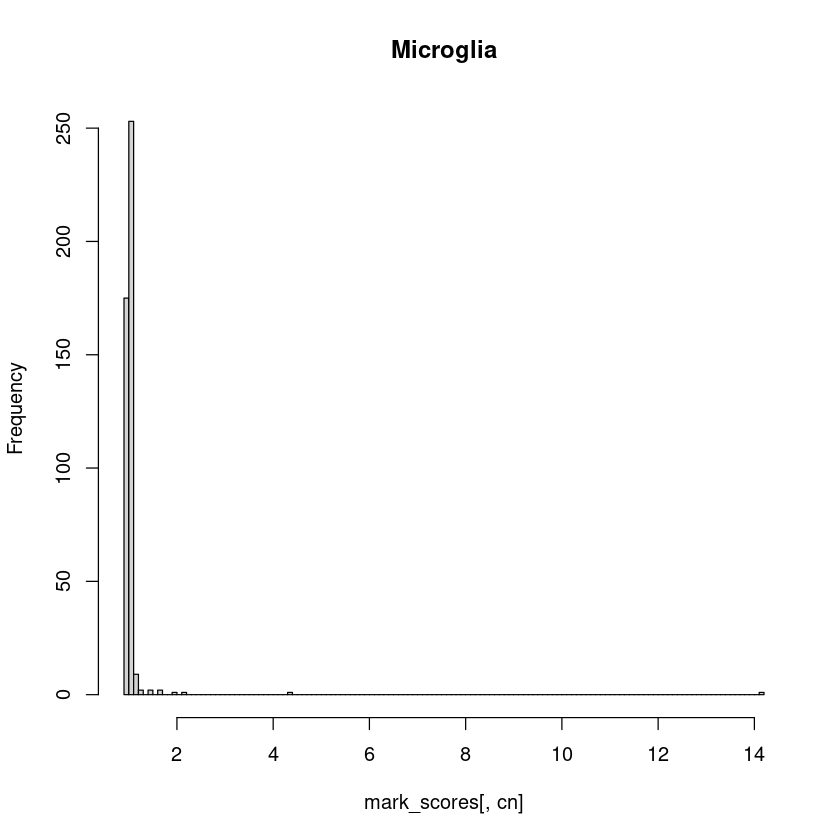

CR                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                
breaks   0.95, 1.00, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35, 1.40, 1.45, 1.50, 1.55, 1.60, 1.65, 1.70, 1.75, 1.80, 1.85, 1.90, 1.95, 2.00, 2.05, 2.10, 2.15, 2.20, 2.25, 2.30, 2.35, 2.40, 2.45, 2.50, 2.55, 2.60, 2.65, 2.70, 2.75, 2.80, 2.85, 2.90, 2.95, 3.00, 3.05, 3.10, 3.15, 3.20, 3.25, 3.30, 3.35, 3.40, 3.45, 3.50, 3.55, 3.60, 3.65, 3.70, 3.75, 3.80, 3.85, 3.90, 3.95, 4.00, 4.05, 4.10, 4.15, 4.20, 4.25, 4.30, 4.35, 4.40, 4.45, 4.50, 4.55, 4.60, 4.65, 4.70, 4.75, 4.80, 4.85, 4.90, 4.95, 5.00, 5.05, 5.10, 5.15, 5.20, 5.25, 5.30, 5.35, 5.40, 5.45, 5.50, 5.55, 5.60, 5.65, 5.70, 5.75, 5.80, 5.85, 5.90, 5.95, 6.00, 6.05, 6.10, 6.15, 6.20, 6.25, 6.30                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
counts   205, 193, 21, 6, 7, 4, 3, 1, 2, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
density  9.17225951, 8.63534676, 0.93959732, 0.26845638, 0.31319911, 0.17897092, 0.13422819, 0.04474273, 0.08948546, 0.00000000, 0.00

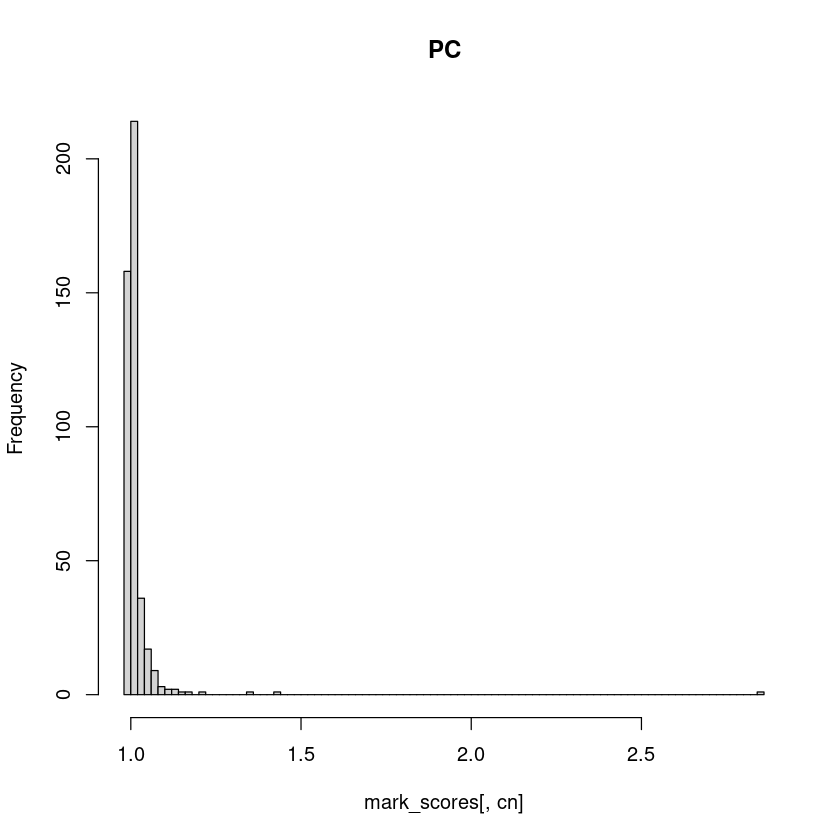

In [193]:
sapply(colnames(mark_scores)[colnames(mark_scores) %in% non_cort_st], function(cn) hist(mark_scores[,cn], 100, main = cn)) 

In [194]:
THRESH = 1.5

In [195]:
put_non_cort = which(apply(mark_scores[,non_cort_st], 1, max) >= THRESH)
put_non_cort
length(put_non_cort)

3  15  28  32  33  34  35  37  38  40  46  48  49  51  60  71  73  76  79  80 
  3  15  28  32  33  34  35  37  38  40  46  48  49  51  60  71  73  76  79  80 
 81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97 108 121 128 
 81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97 108 121 128 
129 130 132 133 134 137 138 142 143 144 147 150 151 152 153 154 160 214 215 233 
129 130 132 133 134 137 138 142 143 144 147 150 151 152 153 154 160 214 215 233 
234 235 236 264 296 297 298 299 300 302 306 307 308 309 312 320 321 326 327 328 
234 235 236 264 296 297 298 299 300 302 306 307 308 309 312 320 321 326 327 328 
329 330 331 332 339 340 341 342 343 344 345 346 347 348 349 350 352 353 354 355 
329 330 331 332 339 340 341 342 343 344 345 346 347 348 349 350 352 353 354 355 
356 357 358 359 360 361 362 363 364 365 366 367 368 369 370 371 372 373 374 375 
356 357 358 359 360 361 362 363 364 365 366 367 368 369 370 371 372 373 374 375 
378 379 380 381 382 383 385 403 410 413 415 417 418 419 420 421 422 423 428 
378 379 380 381 382 383 385 403 410 413 415 417 418 419 420 421 422 423 428

[1] 139

In [196]:
put_cort = which(apply(mark_scores[,!(colnames(mark_scores) %in% non_cort_st)], 1, max) >= THRESH)
put_cort
length(put_cort)

1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 
  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 
 21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40 
 21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40 
 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  60  61 
 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  60  61 
 62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81 
 62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81 
 82  83  85  86  87  89  90  91  92  98  99 100 101 102 103 104 105 106 107 108 
 82  83  85  86  87  89  90  91  92  98  99 100 101 102 103 104 105 106 107 108 
109 110 111 112 113 114 115 116 117 118 119 120 122 123 125 126 127 128 129 130 
109 110 111 112 113 114 115 116 117 118 119 120 122 123 125 126 127 128 129 130 
131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 
131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 
151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 
151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 
171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 
171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 
191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 
191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 
211 212 213 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 
211 212 213 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 
233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 
233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 
253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 
253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 
273 274 275 276 277 278 279 280 281 282 283 284 285 286 287 288 289 290 291 292 
273 274 275 276 277 278 279 280 281 282 283 284 285 286 287 288 289 290 291 292 
293 294 295 296 297 298 299 300 301 302 303 304 306 307 308 309 310 311 312 313 
293 294 295 296 297 298 299 300 301 302 303 304 306 307 308 309 310 311 312 313 
314 315 316 317 318 319 320 321 322 323 324 325 326 327 328 329 330 331 332 333 
314 315 316 317 318 319 320 321 322 323 324 325 326 327 328 329 330 331 332 333 
334 335 337 338 342 343 344 346 347 348 349 350 351 353 354 355 356 357 358 359 
334 335 337 338 342 343 344 346 347 348 349 350 351 353 354 355 356 357 358 359 
360 361 362 365 368 370 372 373 376 377 378 379 380 381 384 385 386 387 388 389 
360 361 362 365 368 370 372 373 376 377 378 379 380 381 384 385 386 387 388 389 
390 391 392 393 394 395 396 397 398 399 400 401 402 403 404 405 406 407 408 409 
390 391 392 393 394 395 396 397 398 399 400 401 402 403 404 405 406 407 408 409 
410 411 412 413 414 415 416 417 418 419 420 421 422 423 424 425 426 427 428 429 
410 411 412 413 414 415 416 417 418 419 420 421 422 423 424 425 426 427 428 429 
430 431 432 433 434 435 436 437 438 439 440 441 442 443 444 445 446 447 
430 431 432 433 434 435 436 437 438 439 440 441 442 443 444 445 446 447

[1] 418

In [197]:
intersect(put_cort, put_non_cort)

[1]   3  15  28  32  33  34  35  37  38  40  46  48  49  51  60  71  73  76
 [19]  79  80  81  82  83  85  86  87  89  90  91  92 108 128 129 130 132 133
 [37] 134 137 138 142 143 144 147 150 151 152 153 154 160 233 234 235 236 264
 [55] 296 297 298 299 300 302 306 307 308 309 312 320 321 326 327 328 329 330
 [73] 331 332 342 343 344 346 347 348 349 350 353 354 355 356 357 358 359 360
 [91] 361 362 365 368 370 372 373 378 379 380 381 385 403 410 413 415 417 418
[109] 419 420 421 422 423 428

In [198]:
which(!(1:nrow(mark_scores) %in% put_cort) & !(1:nrow(mark_scores) %in% put_non_cort))

[1]  59 124 305 336

In [199]:
cond_a = 1:nrow(mark_scores) %in% put_cort
cond_b = 1:nrow(mark_scores) %in% put_non_cort
cond1 = cond_a & !cond_b
cond2 = !cond_a & cond_b
cond3 = cond_a & cond_b
cond4 = !cond_a & !cond_b
cort_bool_cols = setNames(
        c(rep('red', length(which(cond1))),
          rep('blue', length(which(cond2))),
          rep('purple', length(which(cond3))),
          rep('yellow', length(which(cond4)))),
    c(which(cond1), which(cond2), which(cond3), which(cond4))
         )
cort_bool_cols = cort_bool_cols[order(as.numeric(names(cort_bool_cols)))]

In [200]:
table(cmd[names(mc@mc)[mc@mc %in% which(top_3_st[1,] == 'NSC')], 't'])


  12   13   14   15   16   17   18 
4255 2842 1841 1003  670  730  468 

In [243]:
day_chars = as.character(12:18)
prc_day = sapply(1:length(unique(mc@mc)), function(mci) {
#     print(mci)
    tbl = table(cmd[names(mc@mc)[mc@mc == mci], 't']);
    tbl = tbl/sum(tbl);
    tbl[day_chars[!(day_chars %in% names(tbl))]] = 0;
    return(tbl)
#     if ('12' %in% names(tbl)) {return(tbl['12'])}
#     else {return(NULL)}
})

In [244]:
colnames(prc_day) = 1:length(unique(mc@mc))
prc_day = t(prc_day[order(as.numeric(rownames(prc_day))),])
head(prc_day)

,12,13,14,15,16,17,18
1,0,0,0.01851852,0.8981481,0.05555556,0.01851852,0.009259259
2,0,0,0.06896552,0.7816092,0.08045977,0.06896552,0.000000000
3,0,0,0.03448276,0.4137931,0.44827586,0.10344828,0.000000000
4,0,0,0.14084507,0.6901408,0.16901408,0.00000000,0.000000000
5,0,0,0.01086957,0.1630435,0.82608696,0.00000000,0.000000000
6,0,0,0.04819277,0.5180723,0.43373494,0.00000000,0.000000000


In [248]:
top_3_st[,as.numeric(head(rownames(prc_day[order(prc_day[,'12'], decreasing = T),]), 20))]

162,122,235,285,395,89,441,263,401,124,11,439,91,442,84,223,262,426,352,363
CPN_L2-3,CthPN,NSC,NSC,IPC,IN_CGE,IPC,NSC,IPC,NPC_GE,CPN_L2-3,IPC,IN_CGE,IPC,IN_MGE,IPC,NSC,IPC,PC,CR
CPN_L5_6,SCPN,Astrocytes,Oligodendrocytes,CPN_L2-3,IN_MGE,NSC,Astrocytes,CPN_L2-3,NPC_CGE,CPN_L5_6,CPN_L2-3,IN_MGE,NSC,IN_CGE,NSC,CPN_L2-3,CPN_L2-3,NPC_CGE,NPC_CGE
CthPN,CPN_L5_6,Microglia,IPC,NPC_GE,MSN,CPN_L2-3,Microglia,NSC,CPN_L5_6,Stellate_L4,NSC,MSN,CPN_L2-3,MSN,CPN_L2-3,Stellate_L4,NPC_GE,MSN,MSN


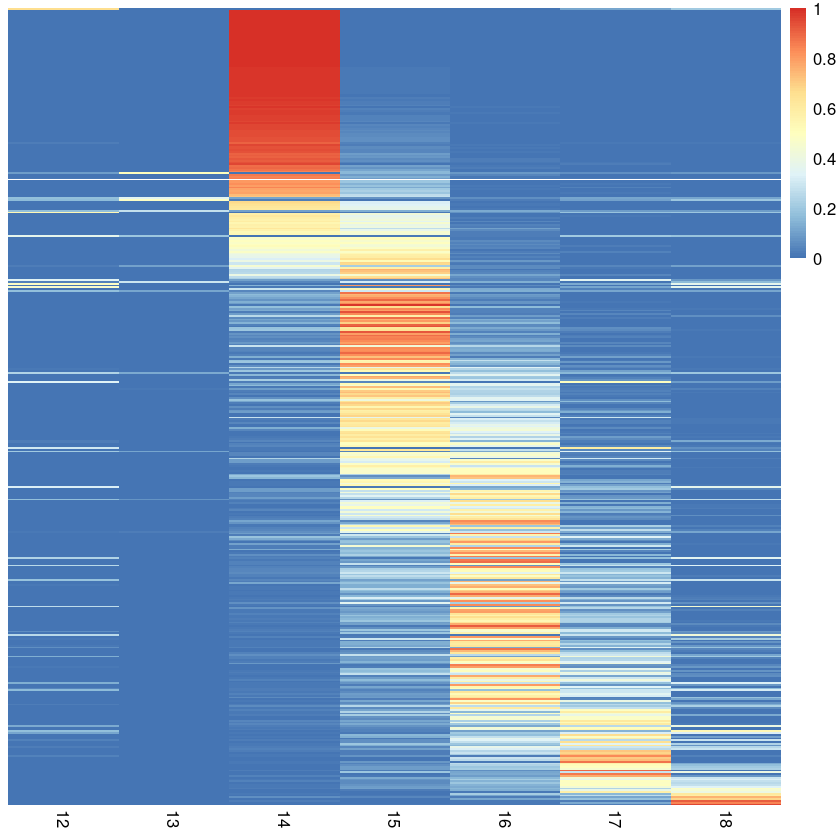

In [231]:
pheatmap::pheatmap(prc_day[order(apply(prc_day, 1, function(x) sum(x*12:18)/sum(x))),], cluster_rows = F, cluster_cols = F)

In [202]:
mcell_mc2d_plot(nm, colors = cort_bool_cols, fn_suf = '_cort_bool')

png 
  2

In [169]:
mcell_mc2d_plot(nm, colors = ifelse(1:nrow(mark_scores) %in% put_non_cort, 'red', 'black'), fn_suf = '_put_non_cort')

png 
  2

In [174]:
mcell_mc2d_plot(nm, colors = ifelse(1:nrow(mark_scores) %in% put_cort, 'red', 'black'), fn_suf = '_put_cort')

png 
  2